In [ ]:
# Clone the repo
!git clone https://github.com/giorgoschionas/concentrator-challenge.git
%cd concentrator-challenge

# Install the two dependencies needed
!pip install gymnasium numpy -q

fatal: destination path 'concentrator-challenge' already exists and is not an empty directory.
/content/concentrator-challenge


In [ ]:
!pip install stable-baselines3
import numpy as np
import gymnasium
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import VecMonitor, VecNormalize

from SAiFE_gym.challenge import ScenarioConfig, create_environment
from SAiFE_gym.gym.StableBaselinesAMMEnvironment import StableBaselinesAMMEnvironment

config = ScenarioConfig()   # official hackathon parameters
seed = 42

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from SAiFE_gym.challenge import ScenarioConfig, create_environment, official_observation
from SAiFE_gym.gym.AMMEnvironment import AMMEnvironment
from SAiFE_gym.gym.index_names import (
    ASSET_PRICE_KEY, POOL_CURRENT_TICK_KEY, LP_TICK_LOWER_KEY, LP_TICK_UPPER_KEY,
    LP_COLLECTED_FEES0_KEY, LP_COLLECTED_FEES1_KEY, PORTFOLIO_VALUE_KEY,
    MISPRICING_KEY, BOUNDARY_PROXIMITY_KEY, POSITION_WIDTH_KEY,
    TIME_KEY, GAS_COST_KEY, LP_EVER_DEPLOYED_KEY,
    POOL_SQRT_PRICE_KEY,
)


In [ ]:
from stable_baselines3.common.vec_env import VecEnv, VecMonitor, VecNormalize
from stable_baselines3.common.vec_env.base_vec_env import VecEnvIndices, VecEnvObs, VecEnvStepReturn
from typing import Any, List, Optional, Sequence, Type

In [ ]:
class ImprovedSB3Wrapper(VecEnv):
    """
    Enhanced SB3 wrapper with:
    1. tick_velocity observation (6th feature)
    2. Shaped reward: in-range bonus + anti-HODL penalty
    3. PnL normalization by portfolio value
    """
    OBS_DIM = 6

    def __init__(self, amm_env, reward_shaping=True,
                 in_range_bonus=0.3, hodl_penalty=0.002):
        self.env = amm_env
        self.reward_shaping = reward_shaping
        self.in_range_bonus = in_range_bonus
        self.hodl_penalty = hodl_penalty

        self.prev_tick = None
        self.steps_out_of_range = None

        flat_obs_space = gymnasium.spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.OBS_DIM,), dtype=np.float32
        )
        old_act = amm_env.action_space
        act_space = gymnasium.spaces.Box(
            low=old_act.low.astype(np.float32),
            high=old_act.high.astype(np.float32),
            shape=old_act.shape, dtype=np.float32,
        )
        super().__init__(amm_env.num_trajectories, flat_obs_space, act_space)

    def reset(self):
        obs, _ = self.env.reset()
        self.prev_tick = None
        self.steps_out_of_range = None
        return self._compute_obs(obs)

    def step_async(self, actions):
        self.actions = actions

    def step_wait(self):
        state_dict, rewards, terminated, truncated, _ = self.env.step(self.actions)
        dones = terminated | truncated
        obs = self._compute_obs(state_dict)
        shaped_rewards = self._shape_reward(state_dict, rewards)
        infos = [{} for _ in range(self.env.num_trajectories)]
        if dones.all():
            for i, info in enumerate(infos):
                info["terminal_observation"] = obs[i]
            reset_obs, _ = self.env.reset()
            self.prev_tick = None
            self.steps_out_of_range = None
            obs = self._compute_obs(reset_obs)
        return obs, shaped_rewards, dones, infos

    def _compute_obs(self, state_dict):
        n = self.env.num_trajectories
        ct = state_dict[POOL_CURRENT_TICK_KEY]
        if self.prev_tick is None:
            velocity = np.zeros(n)
        else:
            velocity = ct - self.prev_tick
        self.prev_tick = ct.copy()

        mispricing = state_dict[ASSET_PRICE_KEY] - state_dict[POOL_SQRT_PRICE_KEY] ** 2
        lower_off = ct - state_dict[LP_TICK_LOWER_KEY]
        upper_off = state_dict[LP_TICK_UPPER_KEY] - ct
        boundary_prox = np.minimum(lower_off, upper_off)
        pos_width = lower_off + upper_off

        obs = np.column_stack([
            mispricing.reshape(n, 1),
            boundary_prox.reshape(n, 1),
            pos_width.reshape(n, 1),
            state_dict[TIME_KEY].reshape(n, 1),
            state_dict[GAS_COST_KEY].reshape(n, 1),
            velocity.reshape(n, 1),
        ]).astype(np.float32)
        return obs

    def _shape_reward(self, state_dict, raw_reward):
        if not self.reward_shaping:
            return raw_reward
        ct = state_dict[POOL_CURRENT_TICK_KEY]
        lo = state_dict[LP_TICK_LOWER_KEY]
        hi = state_dict[LP_TICK_UPPER_KEY]
        ever = state_dict.get(LP_EVER_DEPLOYED_KEY, np.ones(self.env.num_trajectories, dtype=bool))
        in_range = ((ct >= lo) & (ct < hi) & ever).astype(np.float32)
        bonus = in_range * self.in_range_bonus
        if self.steps_out_of_range is None:
            self.steps_out_of_range = np.zeros(self.env.num_trajectories)
        self.steps_out_of_range = np.where(in_range > 0, 0, self.steps_out_of_range + 1)
        anti_hodl = -self.hodl_penalty * np.minimum(self.steps_out_of_range, 50)
        pv = state_dict.get(PORTFOLIO_VALUE_KEY, np.ones(self.env.num_trajectories) * 1000)
        pv_safe = np.maximum(np.abs(pv), 100.0)
        norm_factor = 1000.0 / pv_safe
        return (raw_reward + bonus + anti_hodl) * norm_factor

    def close(self): pass
    def get_attr(self, attr_name, indices=None):
        if attr_name == "render_mode": return [None] * self.env.num_trajectories
        return [getattr(self.env, attr_name)] * self.env.num_trajectories
    def set_attr(self, attr_name, value, indices=None): setattr(self.env, attr_name, value)
    def env_method(self, method_name, *a, indices=None, **kw):
        return [getattr(self.env, method_name)(*a, **kw)] * self.env.num_trajectories
    def env_is_wrapped(self, wrapper_class, indices=None):
        return [False] * self.env.num_trajectories
    def seed(self, seed=None): self.env.seed(seed); return [seed] * self.env.num_trajectories
    def get_images(self): return []

    @property
    def num_trajectories(self):
        return self.env.num_trajectories

    @property
    def n_steps(self):
        return self.env.n_steps

In [ ]:
def _compute_obs(self, state_dict):
        n = self.env.num_trajectories
        ct = state_dict[POOL_CURRENT_TICK_KEY]

        # Tick velocity (new feature — key to learning calm-gating)
        if self.prev_tick is None:
            velocity = np.zeros(n)
        else:
            velocity = ct - self.prev_tick
        self.prev_tick = ct.copy()

        # Derived features (same as original wrapper)
        mispricing = state_dict[ASSET_PRICE_KEY] - state_dict[POOL_SQRT_PRICE_KEY] ** 2
        lower_off = ct - state_dict[LP_TICK_LOWER_KEY]
        upper_off = state_dict[LP_TICK_UPPER_KEY] - ct
        boundary_prox = np.minimum(lower_off, upper_off)
        pos_width = lower_off + upper_off

        obs = np.column_stack([
            mispricing.reshape(n, 1),
            boundary_prox.reshape(n, 1),
            pos_width.reshape(n, 1),
            state_dict[TIME_KEY].reshape(n, 1),
            state_dict[GAS_COST_KEY].reshape(n, 1),
            velocity.reshape(n, 1),              # NEW: feature 6
        ]).astype(np.float32)
        return obs

In [ ]:
 def _shape_reward(self, state_dict, raw_reward):
        """Add auxiliary reward terms. Training-only — eval uses pure PnL."""
        if not self.reward_shaping:
            return raw_reward

        ct = state_dict[POOL_CURRENT_TICK_KEY]
        lo = state_dict[LP_TICK_LOWER_KEY]
        hi = state_dict[LP_TICK_UPPER_KEY]
        ever = state_dict.get(LP_EVER_DEPLOYED_KEY, np.ones(self.env.num_trajectories, dtype=bool))

        # In-range bonus: +bonus when tick is inside our band
        in_range = ((ct >= lo) & (ct < hi) & ever).astype(np.float32)
        bonus = in_range * self.in_range_bonus

        # Anti-HODL: small penalty that grows the longer we're out of range
        # This prevents the agent from collapsing to "never deploy"
        if self.steps_out_of_range is None:
            self.steps_out_of_range = np.zeros(self.env.num_trajectories)
        self.steps_out_of_range = np.where(in_range > 0, 0, self.steps_out_of_range + 1)
        anti_hodl = -self.hodl_penalty * np.minimum(self.steps_out_of_range, 50)

        # Portfolio-normalized: scale reward by inverse wealth (optional)
        pv = state_dict.get(PORTFOLIO_VALUE_KEY, np.ones(self.env.num_trajectories) * 1000)
        pv_safe = np.maximum(np.abs(pv), 100.0)  # avoid division by tiny values
        norm_factor = 1000.0 / pv_safe  # normalize so rewards are % of initial wealth

        return (raw_reward + bonus + anti_hodl) * norm_factor

In [ ]:
def reset(self):
        obs, _ = self.env.reset()
        self.prev_tick = None
        self.steps_out_of_range = None
        return self._compute_obs(obs)

In [ ]:
def step_async(self, actions):
        self.actions = actions

In [ ]:
def step_wait(self):
        state_dict, rewards, terminated, truncated, _ = self.env.step(self.actions)
        dones = terminated | truncated
        obs = self._compute_obs(state_dict)
        shaped_rewards = self._shape_reward(state_dict, rewards)
        infos = [{} for _ in range(self.env.num_trajectories)]
        if dones.all():
            for i, info in enumerate(infos):
                info["terminal_observation"] = obs[i]
            reset_obs, _ = self.env.reset()
            self.prev_tick = None
            self.steps_out_of_range = None
            obs = self._compute_obs(reset_obs)
        return obs, shaped_rewards, dones, infos

In [ ]:
def close(self): pass
def get_attr(self, attr_name, indices=None):
        if attr_name == "render_mode": return [None] * self.env.num_trajectories
        return [getattr(self.env, attr_name)] * self.env.num_trajectories
def set_attr(self, attr_name, value, indices=None): setattr(self.env, attr_name, value)
def env_method(self, method_name, *a, indices=None, **kw):
        return [getattr(self.env, method_name)(*a, **kw)] * self.env.num_trajectories
def env_is_wrapped(self, wrapper_class, indices=None):
        return [False] * self.env.num_trajectories
def seed(self, seed=None): self.env.seed(seed); return [seed] * self.env.num_trajectories
def get_images(self): return []
@property
def num_trajectories(self): return self.env.num_trajectories
@property
def n_steps(self): return self.env.n_steps
print("✓ ImprovedSB3Wrapper defined")
print("  6 obs features: mispricing, boundary_prox, position_width, time, gas_cost, tick_velocity")
print("  Reward shaping: in_range_bonus=0.3, hodl_penalty=0.002")


✓ ImprovedSB3Wrapper defined
  6 obs features: mispricing, boundary_prox, position_width, time, gas_cost, tick_velocity
  Reward shaping: in_range_bonus=0.3, hodl_penalty=0.002


In [ ]:
config = ScenarioConfig()
seed = 42

# Training env: WITH reward shaping
train_env_raw = create_environment(config, seed=seed)
train_env = VecNormalize(
    VecMonitor(ImprovedSB3Wrapper(train_env_raw, reward_shaping=True)),
    norm_obs=True, norm_reward=False, clip_obs=10.0,
)

# Eval env: WITHOUT reward shaping (pure PnL)
eval_env_raw = create_environment(config, seed=seed + 100)
eval_env = VecNormalize(
    VecMonitor(ImprovedSB3Wrapper(eval_env_raw, reward_shaping=False)),
    norm_obs=True, norm_reward=False, clip_obs=10.0, training=False,
)

print("Environments initialized successfully.")

Environments initialized successfully.


In [ ]:
rollout_size = config.n_steps * config.num_trajectories

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    policy_kwargs=dict(
        net_arch=dict(pi=[64, 64], vf=[64, 64]),
    ),
    learning_rate=3e-4,
    n_epochs=10,
    batch_size=max(64, rollout_size // 16),
    normalize_advantage=True,
    n_steps=config.n_steps,
    gae_lambda=0.95,
    gamma=1.0,
    clip_range=0.2,
    ent_coef=0.05,            # ← KEY CHANGE: forces exploration, prevents HODL collapse
    seed=seed,
)

Using cuda device


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import os
os.makedirs("best_models_v2", exist_ok=True)
eval_callback = EvalCallback(
    eval_env,
    n_eval_episodes=5,
    best_model_save_path="best_models_v2/",
    deterministic=True,
    eval_freq=rollout_size * 3,
    verbose=1,
)

In [ ]:
TOTAL_TIMESTEPS = 3_000_000
print(f"Training improved PPO for {TOTAL_TIMESTEPS:,} timesteps")
print(f"  Obs: 6 features (added tick_velocity)")
print(f"  Reward: shaped (in-range bonus + anti-HODL)")
print(f"  ent_coef: 0.05 (anti mode-collapse)")
print(f"  Network: 6 → 64 (tanh) → 64 (tanh) → 3")

Training improved PPO for 3,000,000 timesteps
  Obs: 6 features (added tick_velocity)
  Reward: shaped (in-range bonus + anti-HODL)
  ent_coef: 0.05 (anti mode-collapse)
  Network: 6 → 64 (tanh) → 64 (tanh) → 3


In [ ]:
import time
t0 = time.time()
model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback, progress_bar=True)
elapsed = time.time() - t0

model.save("ppo_v2_final")
train_env.save("vecnormalize_v2_stats.pkl")
print(f"\n✓ Training complete in {elapsed/60:.1f} min")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/content/concentrator-challenge/SAiFE_gym/gym/ModelDynamics.py:441: RuntimeWarning: invalid value encountered in 
divide
  alpha_current = np.where(wealth_with_pos > 0, token0_value / wealth_with_pos, 0.0)

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 1e+03     |
|    ep_rew_mean     | -3.07e+03 |
| time/              |           |
|    fps             | 817       |
|    iterations      | 1         |
|    time_elapsed    | 122       |
|    total_timesteps | 100000    |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -3.07e+03   |
| time/                   |             |
|    fps                  | 807         |
|    iterations           | 2           |
|    time_elapsed         | 247         |
|    total_timesteps      | 200000      |
| train/                  |             |
|    approx_kl            | 0.004527038 |
|    clip_fraction        | 0.0322      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.3        |
|    explained_variance   | 0.000115    |
|    learning_rate  


✓ Training complete in 39.7 min


In [ ]:
best_path = "best_models_v2/best_model.zip"
if os.path.exists(best_path):
    print("Loading BEST model from eval callback...")
    model = PPO.load(best_path, env=train_env)
else:
    print("Using final model...")

# VecNormalize stats (now 6 features)
obs_mean = train_env.obs_rms.mean.astype(np.float64)
obs_var  = train_env.obs_rms.var.astype(np.float64)
clip_obs = float(train_env.clip_obs)

feat_names = ['mispricing', 'boundary_prox', 'position_width', 'time', 'gas_cost', 'tick_velocity']
print("=== Normalization Stats (6 features) ===")
for i, name in enumerate(feat_names):
    print(f"  {name:20s}: mean={obs_mean[i]:+.6f}, std={np.sqrt(obs_var[i]):.6f}")

Using final model...
=== Normalization Stats (6 features) ===
  mispricing          : mean=+0.001623, std=0.621122
  boundary_prox       : mean=-2.403780, std=3.413825
  position_width      : mean=+1.732307, std=1.900349
  time                : mean=+0.499483, std=0.288685
  gas_cost            : mean=+3.000000, std=0.000018
  tick_velocity       : mean=+0.001404, std=0.952177


In [ ]:
# Policy weights
policy = model.policy
pi_layers = policy.mlp_extractor.policy_net
W1 = pi_layers[0].weight.detach().cpu().numpy().astype(np.float64)   # (64, 6)
b1 = pi_layers[0].bias.detach().cpu().numpy().astype(np.float64)     # (64,)
W2 = pi_layers[2].weight.detach().cpu().numpy().astype(np.float64)   # (64, 64)
b2 = pi_layers[2].bias.detach().cpu().numpy().astype(np.float64)     # (64,)
W3 = policy.action_net.weight.detach().cpu().numpy().astype(np.float64)  # (3, 64)
b3 = policy.action_net.bias.detach().cpu().numpy().astype(np.float64)    # (3,)
act_low  = model.policy.action_space.low.astype(np.float64)
act_high = model.policy.action_space.high.astype(np.float64)

print(f"\n=== Policy Network ===")
print(f"  Layer 1: {W1.shape}  (was 64×5, now 64×6)")
print(f"  Layer 2: {W2.shape}")
print(f"  Output:  {W3.shape}")
total_params = sum(w.size for w in [W1,b1,W2,b2,W3,b3])
print(f"  Total: {total_params:,} parameters")


=== Policy Network ===
  Layer 1: (64, 6)  (was 64×5, now 64×6)
  Layer 2: (64, 64)
  Output:  (3, 64)
  Total: 4,803 parameters


In [ ]:
# Verify forward pass
test_obs = train_env.reset()
sb3_action, _ = model.predict(test_obs, deterministic=True)
x = test_obs.astype(np.float64)
h = np.tanh(x @ W1.T + b1)
h = np.tanh(h @ W2.T + b2)
np_action = h @ W3.T + b3
np_action = np.clip(np_action, act_low, act_high)
max_diff = np.max(np.abs(sb3_action.astype(np.float64) - np_action))
print(f"\n  Verification: max |SB3 - numpy| = {max_diff:.2e}  {'✓' if max_diff < 1e-4 else '⚠'}")


  Verification: max |SB3 - numpy| = 3.71e-08  ✓


In [ ]:
def arr_to_string(arr):
    flat = arr.flatten().astype(np.float64)
    return ",".join(f"{v:.4e}" for v in flat)

def make_line(arr, varname, indent=8):
    s = arr_to_string(arr)
    sp = " " * indent
    return f'{sp}self.{varname} = np.fromstring(\n{sp}    "{s}",\n{sp}    sep=",").reshape({repr(arr.shape)})'

In [ ]:
code_parts = []
code_parts.append('''"""
Improved RL Agent — Adaptive-Width Concentrator (v2)

PPO policy trained with:
  - 6 observations (added tick_velocity for calm-gating)
  - Reward shaping (in-range bonus + anti-HODL penalty)
  - Entropy bonus (anti mode-collapse)
  - Variable LP width (agent chooses lower/upper offsets adaptively)

The agent learns WHEN to rebalance (calm moments) and HOW WIDE to set the band
(tight when stable, wider when volatile).
"""

import numpy as np


class Agent:
    def __init__(self, config):
        self.tau = int(getattr(config, "tau", 10))
        self.prev_tick = None
''')

In [ ]:
code_parts.append("        # === VecNormalize stats (6 features) ===")
code_parts.append(make_line(obs_mean, "obs_mean"))
code_parts.append(make_line(obs_var, "obs_var"))
code_parts.append(f"        self.clip_obs = {clip_obs}")
code_parts.append("")
code_parts.append("        # === Policy network: 6 → 64 (tanh) → 64 (tanh) → 3 ===")
code_parts.append("        # Layer 1")
code_parts.append(make_line(W1, "W1"))
code_parts.append(make_line(b1, "b1"))
code_parts.append("        # Layer 2")
code_parts.append(make_line(W2, "W2"))
code_parts.append(make_line(b2, "b2"))
code_parts.append("        # Action head")
code_parts.append(make_line(W3, "W3"))
code_parts.append(make_line(b3, "b3"))
code_parts.append("")
code_parts.append("        # Action bounds")
code_parts.append(make_line(act_low, "act_low"))
code_parts.append(make_line(act_high, "act_high"))


In [ ]:
code_parts.append('''
    def get_action(self, state):
        sqrt_price    = np.asarray(state["sqrt_price"],    dtype=np.float64)
        current_tick  = np.asarray(state["current_tick"],  dtype=np.float64)
        midprice      = np.asarray(state["midprice"],      dtype=np.float64)
        time_val      = np.asarray(state["time"],          dtype=np.float64)
        lp_tick_lower = np.asarray(state["lp_tick_lower"], dtype=np.float64)
        lp_tick_upper = np.asarray(state["lp_tick_upper"], dtype=np.float64)
        gas_cost      = np.asarray(state["gas_cost"],      dtype=np.float64)
        n = sqrt_price.shape[0]

        # Compute tick velocity (tracks pool tick movement between steps)
        if self.prev_tick is None or self.prev_tick.shape[0] != n:
            velocity = np.zeros(n)
        else:
            velocity = current_tick - self.prev_tick
        self.prev_tick = current_tick.copy()

        # 6 observation features
        mispricing         = midprice - sqrt_price ** 2
        lower_offset       = current_tick - lp_tick_lower
        upper_offset       = lp_tick_upper - current_tick
        boundary_proximity = np.minimum(lower_offset, upper_offset)
        position_width     = lower_offset + upper_offset

        obs = np.column_stack([
            mispricing, boundary_proximity, position_width,
            time_val, gas_cost, velocity,
        ])

        # Normalize
        obs_norm = (obs - self.obs_mean) / np.sqrt(self.obs_var + 1e-8)
        obs_norm = np.clip(obs_norm, -self.clip_obs, self.clip_obs)

        # Forward pass
        h = np.tanh(obs_norm @ self.W1.T + self.b1)
        h = np.tanh(h @ self.W2.T + self.b2)
        action = h @ self.W3.T + self.b3
        action = np.clip(action, self.act_low, self.act_high)

        return action
''')

In [ ]:
submission_code = "\n".join(code_parts)
file_size = len(submission_code.encode('utf-8'))
print(f"Submission file size: {file_size:,} bytes ({file_size/1024:.1f} KB)")
print(f"{'✓ Within' if file_size <= 65536 else '⚠ OVER'} 64KB limit")

with open("my_rl_agent_v2.py", "w") as f:
    f.write(submission_code)
print("✓ Written: my_rl_agent_v2.py")

Submission file size: 58,880 bytes (57.5 KB)
✓ Within 64KB limit
✓ Written: my_rl_agent_v2.py


In [ ]:
import importlib.util
from SAiFE_gym.agents.BaselineAgents import HoldToken0Agent, DeployOnceWideAgent

# Load agents
def load_agent_class(path):
    spec = importlib.util.spec_from_file_location("a", path)
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    return mod.Agent

AgentV2 = load_agent_class("my_rl_agent_v2.py")

# Also load rule-based agent if available
try:
    AgentRB = load_agent_class("my_agent.py")
    has_rule_based = True
    print("✓ Loaded both my_rl_agent_v2.py and my_agent.py (rule-based)")
except:
    has_rule_based = False
    print("✓ Loaded my_rl_agent_v2.py (rule-based agent not found)")

✓ Loaded my_rl_agent_v2.py (rule-based agent not found)


In [ ]:
def batch_evaluate(build_agent, seeds=[42, 314, 2718]):
    """Run all seeds in batch, collect per-trajectory diagnostics."""
    cfg = ScenarioConfig()
    results = []

    for s in seeds:
        env = create_environment(cfg, seed=s)
        agent = build_agent(cfg)
        state, _ = env.reset()
        obs = official_observation(state, env)
        n = cfg.num_trajectories

        cum_reward = np.zeros(n)
        cum_fees0 = np.zeros(n); cum_fees1 = np.zeros(n)
        n_rebalances = np.zeros(n)
        n_in_range = np.zeros(n)
        widths_used = []
        portfolio_values = [np.full(n, 1000.0)]
        terminated = np.zeros(n, dtype=bool)
        steps = 0

        while not np.any(terminated):
            action = np.asarray(agent.get_action(obs), dtype=np.float64)

            # Track rebalances
            rebal_mask = action[:, 2] <= 0
            n_rebalances += rebal_mask.astype(float)

            # Track width chosen when rebalancing
            if rebal_mask.any():
                w = action[rebal_mask, 1] - action[rebal_mask, 0]
                widths_used.extend(w.tolist())

            # Track in-range
            ct = state[POOL_CURRENT_TICK_KEY]
            lo = state[LP_TICK_LOWER_KEY]; hi = state[LP_TICK_UPPER_KEY]
            n_in_range += ((ct >= lo) & (ct < hi)).astype(float)

            # Step
            prev_f0 = state[LP_COLLECTED_FEES0_KEY].copy()
            prev_f1 = state[LP_COLLECTED_FEES1_KEY].copy()

            state, reward, terminated, _, _ = env.step(action)
            obs = official_observation(state, env)
            cum_reward += reward

            # Fee increment
            price = state[ASSET_PRICE_KEY]
            cum_fees0 += (state[LP_COLLECTED_FEES0_KEY] - prev_f0)
            cum_fees1 += (state[LP_COLLECTED_FEES1_KEY] - prev_f1)

            portfolio_values.append(state.get(PORTFOLIO_VALUE_KEY, np.full(n, np.nan)).copy())
            steps += 1

        fee_total = cum_fees0 * state[ASSET_PRICE_KEY] + cum_fees1
        gas_total = np.maximum(n_rebalances - 1, 0) * cfg.gas_cost
        in_range_pct = n_in_range / steps

        results.append(dict(
            pnl=cum_reward, fees=fee_total, gas=gas_total,
            rebalances=n_rebalances, in_range_pct=in_range_pct,
            adv_sel=fee_total - gas_total - cum_reward,
            pnl_normalized=cum_reward / 1000.0 * 100,  # as % of initial wealth
            widths_used=widths_used,
            portfolio_values=np.array(portfolio_values),  # (steps+1, n)
        ))
    # Concatenate across seeds
    out = {}
    for key in ['pnl', 'fees', 'gas', 'rebalances', 'in_range_pct', 'adv_sel', 'pnl_normalized']:
        out[key] = np.concatenate([r[key] for r in results])
    out['widths_used'] = sum([r['widths_used'] for r in results], [])
    out['portfolio_values_seed0'] = results[0]['portfolio_values']
    return out

In [ ]:
print("Running evaluations... (takes ~3-5 min)")
t0 = time.time()

res_v2 = batch_evaluate(lambda cfg: AgentV2(cfg.submission_namespace()))
res_hodl = batch_evaluate(lambda cfg: HoldToken0Agent(create_environment(ScenarioConfig(), seed=42)))

Running evaluations... (takes ~3-5 min)


/content/concentrator-challenge/SAiFE_gym/gym/ModelDynamics.py:441: RuntimeWarning: invalid value encountered in divide
  alpha_current = np.where(wealth_with_pos > 0, token0_value / wealth_with_pos, 0.0)


In [ ]:
# Fix: HODL agent needs env, re-do properly
def run_baseline(AgentClass, **kwargs):
    cfg = ScenarioConfig()
    results = []
    for s in [42, 314, 2718]:
        env = create_environment(cfg, seed=s)
        agent = AgentClass(env, **kwargs)
        state, _ = env.reset()
        obs = official_observation(state, env)
        cr = np.zeros(cfg.num_trajectories)
        f0 = np.zeros(cfg.num_trajectories); f1 = np.zeros(cfg.num_trajectories)
        nr = np.zeros(cfg.num_trajectories); nir = np.zeros(cfg.num_trajectories)
        terminated = np.zeros(cfg.num_trajectories, dtype=bool); steps = 0
        while not np.any(terminated):
            action = np.asarray(agent.get_action(obs), dtype=np.float64)
            nr += (action[:, 2] <= 0).astype(float)
            ct = state[POOL_CURRENT_TICK_KEY]; lo = state[LP_TICK_LOWER_KEY]; hi = state[LP_TICK_UPPER_KEY]
            nir += ((ct >= lo) & (ct < hi)).astype(float)
            pf0 = state[LP_COLLECTED_FEES0_KEY].copy(); pf1 = state[LP_COLLECTED_FEES1_KEY].copy()
            state, reward, terminated, _, _ = env.step(action)
            obs = official_observation(state, env)
            cr += reward; f0 += (state[LP_COLLECTED_FEES0_KEY]-pf0); f1 += (state[LP_COLLECTED_FEES1_KEY]-pf1)
            steps += 1
        ft = f0*state[ASSET_PRICE_KEY]+f1; gt = np.maximum(nr-1,0)*cfg.gas_cost
        results.append(dict(pnl=cr,fees=ft,gas=gt,rebalances=nr,in_range_pct=nir/steps,
                           adv_sel=ft-gt-cr, pnl_normalized=cr/1000*100))
    out = {}
    for k in ['pnl','fees','gas','rebalances','in_range_pct','adv_sel','pnl_normalized']:
        out[k] = np.concatenate([r[k] for r in results])
    return out

In [ ]:
res_hodl = run_baseline(HoldToken0Agent)
res_wide = run_baseline(DeployOnceWideAgent)
if has_rule_based:
    res_rb = batch_evaluate(lambda cfg: AgentRB(cfg.submission_namespace()))

print(f"✓ Evaluations complete in {time.time()-t0:.0f}s")

✓ Evaluations complete in 256s


In [ ]:
# Print summary
def print_summary(name, r):
    print(f"  {name:30s} | PnL {r['pnl'].mean():+7.1f} (std {r['pnl'].std():5.1f}) | "
          f"fees {r['fees'].mean():6.1f} | gas {r['gas'].mean():5.1f} | "
          f"in-range {100*r['in_range_pct'].mean():4.1f}% | "
          f"prof {100*np.mean(r['pnl']>0):5.1f}%")

print("\n" + "="*110)
print_summary("RL Agent v2 (improved)", res_v2)
if has_rule_based:
    print_summary("Rule-based CGC (my_agent.py)", res_rb)
print_summary("HoldToken0 (baseline)", res_hodl)
print_summary("DeployOnceWide (baseline)", res_wide)
print("="*110)


  RL Agent v2 (improved)         | PnL   +55.8 (std  28.2) | fees   89.4 | gas  20.3 | in-range 14.1% | prof  98.3%
  HoldToken0 (baseline)          | PnL   +24.4 (std  22.5) | fees   28.7 | gas   0.0 | in-range  1.2% | prof  88.3%
  DeployOnceWide (baseline)      | PnL   +21.5 (std  18.9) | fees   25.5 | gas   0.0 | in-range 18.3% | prof  87.7%


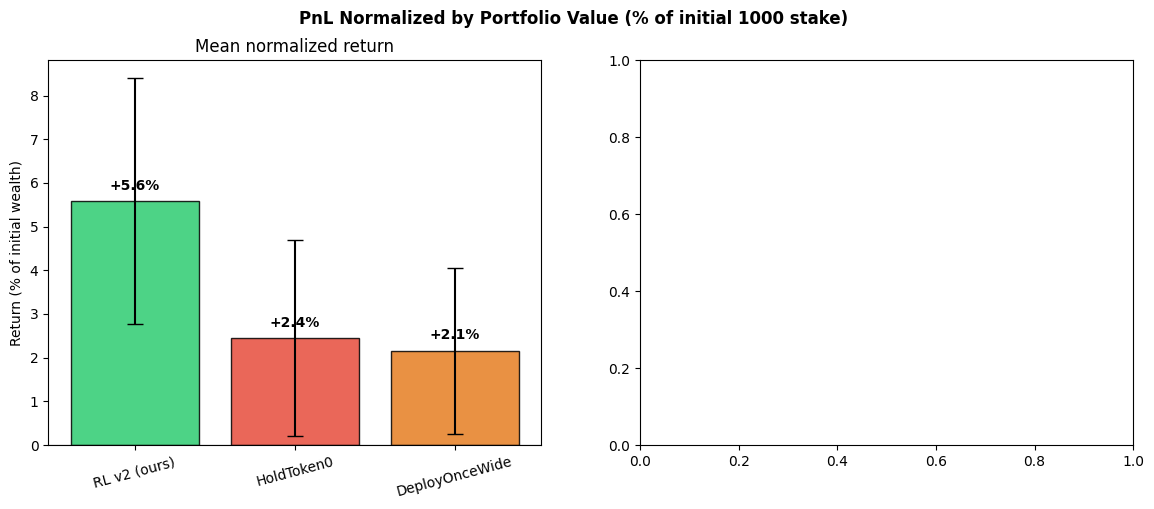

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PnL Normalized by Portfolio Value (% of initial 1000 stake)", fontweight='bold')

agents_data = [("RL v2 (ours)", res_v2, '#2ecc71'), ("HoldToken0", res_hodl, '#e74c3c'),
               ("DeployOnceWide", res_wide, '#e67e22')]
if has_rule_based:
    agents_data.insert(1, ("Rule-based CGC", res_rb, '#3498db'))

# Bar chart of normalized PnL
ax = axes[0]
names = [a[0] for a in agents_data]
means = [a[1]['pnl_normalized'].mean() for a in agents_data]
stds = [a[1]['pnl_normalized'].std() for a in agents_data]
cols = [a[2] for a in agents_data]
bars = ax.bar(names, means, color=cols, alpha=0.85, edgecolor='black')
ax.errorbar(names, means, yerr=stds, fmt='none', color='black', capsize=6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Return (% of initial wealth)")
ax.set_title("Mean normalized return")
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.2, f"{m:+.1f}%", ha='center', va='bottom', fontweight='bold')
ax.tick_params(axis='x', rotation=15)

In [ ]:
# Distribution
ax = axes[1]
for name, res, col in agents_data:
    ax.hist(res['pnl_normalized'], bins=30, alpha=0.5, color=col, label=name, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel("Return (%)")
ax.set_ylabel("Count")
ax.set_title("Return distribution (300 paths)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("plot1_normalized_pnl.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot1_normalized_pnl.png")

<Figure size 640x480 with 0 Axes>

Saved: plot1_normalized_pnl.png


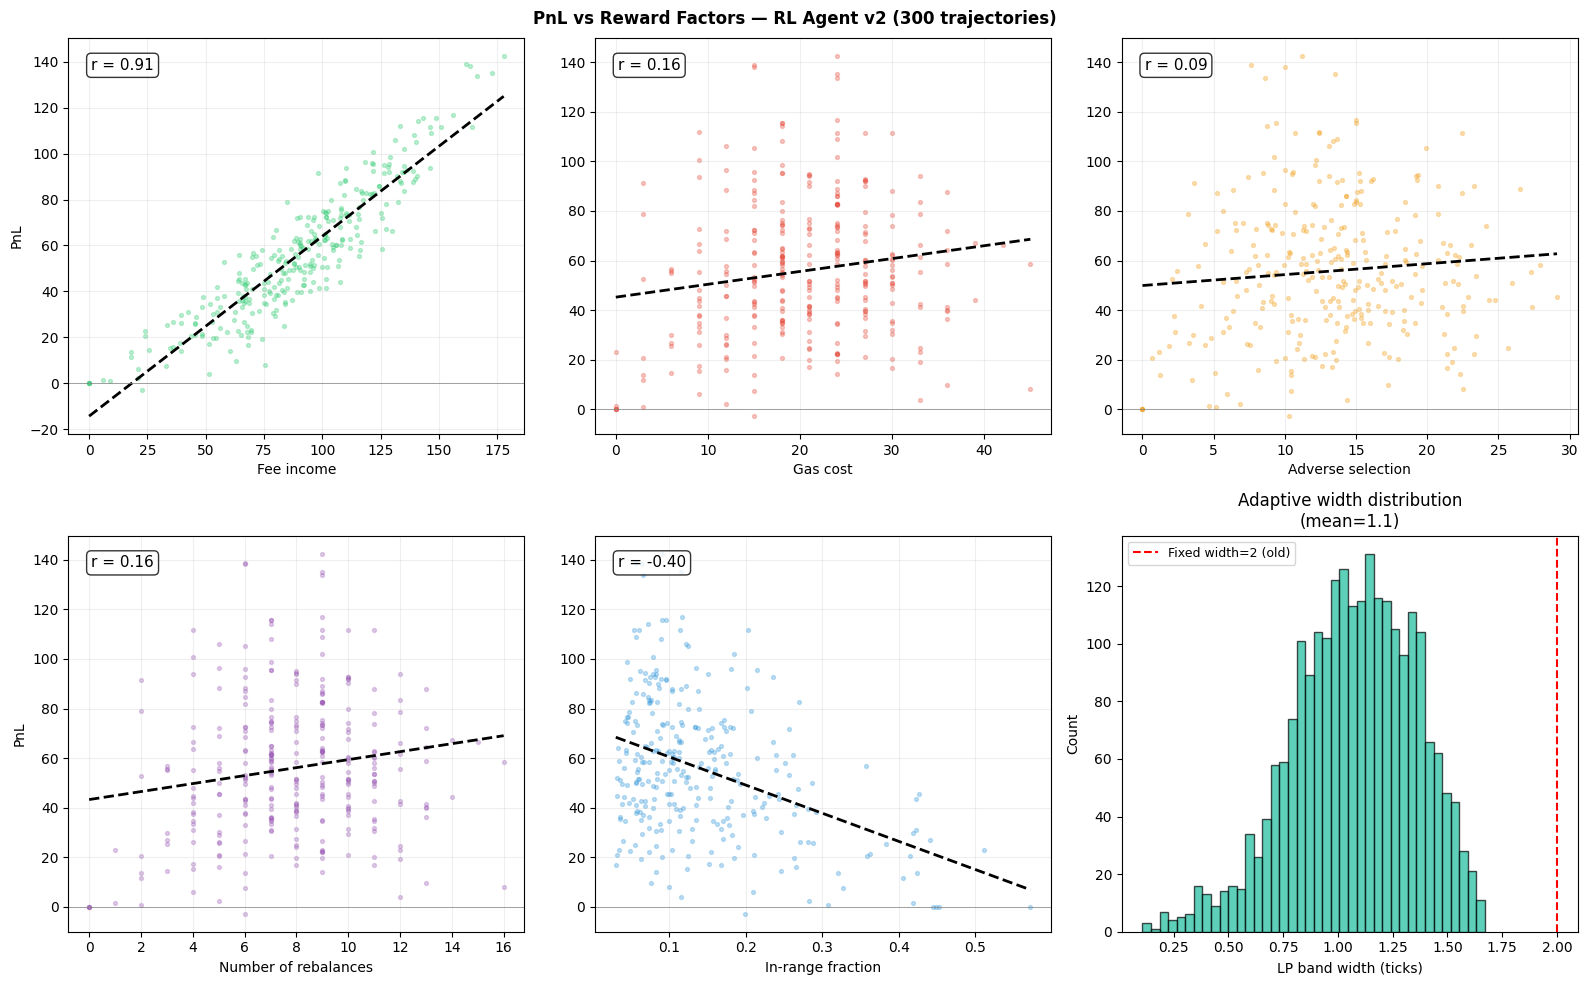

Saved: plot2_pnl_vs_factors.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("PnL vs Reward Factors — RL Agent v2 (300 trajectories)", fontweight='bold')

factors = [
    ('fees', 'Fee income', '#2ecc71'),
    ('gas', 'Gas cost', '#e74c3c'),
    ('adv_sel', 'Adverse selection', '#f39c12'),
    ('rebalances', 'Number of rebalances', '#9b59b6'),
    ('in_range_pct', 'In-range fraction', '#3498db'),
]

pnl = res_v2['pnl']
for i, (key, label, col) in enumerate(factors):
    ax = axes[i // 3, i % 3]
    vals = res_v2[key]
    ax.scatter(vals, pnl, alpha=0.3, s=8, color=col)
    # Trend line
    if np.std(vals) > 1e-10:
        z = np.polyfit(vals, pnl, 1)
        x_line = np.linspace(vals.min(), vals.max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), color='black', linewidth=2, linestyle='--')
        corr = np.corrcoef(vals, pnl)[0, 1]
        ax.text(0.05, 0.95, f"r = {corr:.2f}", transform=ax.transAxes, fontsize=11,
                va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel(label)
    ax.set_ylabel("PnL" if i % 3 == 0 else "")
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.grid(alpha=0.2)

# Width distribution in last subplot
ax = axes[1, 2]
if res_v2['widths_used']:
    ax.hist(res_v2['widths_used'], bins=40, color='#1abc9c', alpha=0.7, edgecolor='black')
    ax.set_xlabel("LP band width (ticks)")
    ax.set_ylabel("Count")
    ax.set_title(f"Adaptive width distribution\n(mean={np.mean(res_v2['widths_used']):.1f})")
    ax.axvline(2, color='red', linestyle='--', label='Fixed width=2 (old)')
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No rebalances\n(HODL policy)", ha='center', va='center',
            transform=ax.transAxes, fontsize=12, color='gray')

plt.tight_layout()
plt.savefig("plot2_pnl_vs_factors.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot2_pnl_vs_factors.png")

In [ ]:
for feat_idx in range(6):
    ax = axes[feat_idx // 3, feat_idx % 3]

    # Sweep this feature from -3σ to +3σ in raw space
    raw_low = obs_mean[feat_idx] - 3 * obs_std[feat_idx]
    raw_high = obs_mean[feat_idx] + 3 * obs_std[feat_idx]
    sweep_raw = np.linspace(raw_low, raw_high, n_sweep)

    # Build observation matrix: all features at mean except the swept one
    obs_matrix = np.tile(obs_mean, (n_sweep, 1))
    obs_matrix[:, feat_idx] = sweep_raw

    # Normalize (replicate VecNormalize)
    obs_norm = (obs_matrix - obs_mean) / obs_std
    obs_norm = np.clip(obs_norm, -clip_obs, clip_obs)

    # Forward pass through policy
    h = np.tanh(obs_norm @ W1.T + b1)
    h = np.tanh(h @ W2.T + b2)
    actions = h @ W3.T + b3
    actions = np.clip(actions, act_low, act_high)

    # Plot each action dimension
    for a_idx in range(3):
        ax.plot(sweep_raw, actions[:, a_idx], color=action_colors[a_idx],
                linewidth=2, label=action_names[a_idx] if feat_idx == 0 else None)

    ax.set_xlabel(feature_names[feat_idx], fontsize=11)
    ax.set_ylabel("Action value" if feat_idx % 3 == 0 else "")
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(obs_mean[feat_idx], color='gray', linewidth=0.5, linestyle=':')
    ax.grid(alpha=0.2)

    # Highlight the hold_flag = 0 line (rebalance threshold)
    ax.axhline(0, color='#2ecc71', linewidth=0.8, linestyle=':', alpha=0.5)

# Shared legend
handles = [plt.Line2D([0],[0], color=c, linewidth=2) for c in action_colors]
fig.legend(handles, action_names, loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 0.92, 0.95])
plt.savefig("plot3_partial_dependence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot3_partial_dependence.png")
print("\nKey things to look for:")
print("  - Does hold_flag (green) go negative when boundary_proximity is negative? (= rebalance when out of range)")
print("  - Does hold_flag respond to tick_velocity? (= calm-gating)")
print("  - Do lower/upper offsets change with features? (= adaptive width)")

<Figure size 640x480 with 0 Axes>

Saved: plot3_partial_dependence.png

Key things to look for:
  - Does hold_flag (green) go negative when boundary_proximity is negative? (= rebalance when out of range)
  - Does hold_flag respond to tick_velocity? (= calm-gating)
  - Do lower/upper offsets change with features? (= adaptive width)


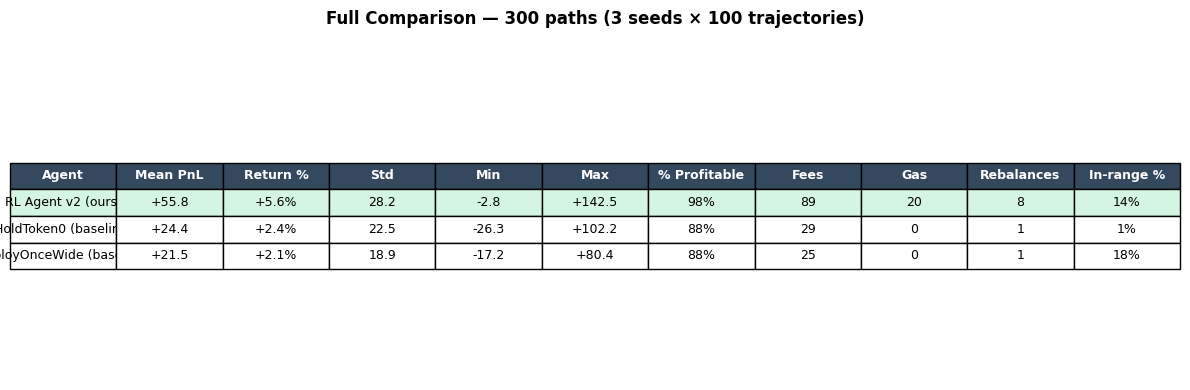

Saved: plot4_comparison_table.png

ALL PLOTS SAVED. Download from Colab sidebar (folder icon):
  1. plot1_normalized_pnl.png     — Normalized PnL comparison
  2. plot2_pnl_vs_factors.png     — PnL vs each reward factor
  3. plot3_partial_dependence.png  — Explainable RL (what drives decisions)
  4. plot4_comparison_table.png    — Full results table
  5. my_rl_agent_v2.py            — Submission file


In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

columns = ['Agent', 'Mean PnL', 'Return %', 'Std', 'Min', 'Max', '% Profitable',
           'Fees', 'Gas', 'Rebalances', 'In-range %']

rows = []
def add_row(name, r):
    rows.append([name,
                 f"{r['pnl'].mean():+.1f}", f"{r['pnl_normalized'].mean():+.1f}%",
                 f"{r['pnl'].std():.1f}", f"{r['pnl'].min():+.1f}", f"{r['pnl'].max():+.1f}",
                 f"{100*np.mean(r['pnl']>0):.0f}%",
                 f"{r['fees'].mean():.0f}", f"{r['gas'].mean():.0f}",
                 f"{r['rebalances'].mean():.0f}", f"{100*r['in_range_pct'].mean():.0f}%"])

add_row("RL Agent v2 (ours)", res_v2)
if has_rule_based:
    add_row("Rule-based CGC", res_rb)
add_row("HoldToken0 (baseline)", res_hodl)
add_row("DeployOnceWide (baseline)", res_wide)

table = ax.table(cellText=rows, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Color the header
for j in range(len(columns)):
    table[0, j].set_facecolor('#34495e')
    table[0, j].set_text_props(color='white', fontweight='bold')
# Highlight our agent
for j in range(len(columns)):
    table[1, j].set_facecolor('#d5f5e3')

plt.title("Full Comparison — 300 paths (3 seeds × 100 trajectories)", fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("plot4_comparison_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot4_comparison_table.png")

print("\n" + "="*80)
print("ALL PLOTS SAVED. Download from Colab sidebar (folder icon):")
print("  1. plot1_normalized_pnl.png     — Normalized PnL comparison")
print("  2. plot2_pnl_vs_factors.png     — PnL vs each reward factor")
print("  3. plot3_partial_dependence.png  — Explainable RL (what drives decisions)")
print("  4. plot4_comparison_table.png    — Full results table")
print("  5. my_rl_agent_v2.py            — Submission file")
print("="*80)

In [ ]:
###############################################################################
# CELL A: Collect detailed metrics for ALL agents (batch)
###############################################################################

import sys, os, importlib.util
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt

from SAiFE_gym.challenge import ScenarioConfig, create_environment, official_observation
from SAiFE_gym.gym.index_names import (
    ASSET_PRICE_KEY, POOL_CURRENT_TICK_KEY, LP_TICK_LOWER_KEY, LP_TICK_UPPER_KEY,
    LP_COLLECTED_FEES0_KEY, LP_COLLECTED_FEES1_KEY, PORTFOLIO_VALUE_KEY,
)
from SAiFE_gym.agents.BaselineAgents import HoldToken0Agent, DeployOnceWideAgent

def load_agent(path):
    spec = importlib.util.spec_from_file_location("a", path)
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    return mod.Agent

# Load our agents
RuleBasedAgent = load_agent("my_agent.py")
RLAgent = load_agent("my_rl_agent.py")

def evaluate_agent(build_fn, name, seeds=[42, 314, 2718]):
    """Run all seeds, collect per-trajectory diagnostics."""
    cfg = ScenarioConfig()
    all_pnl, all_fees, all_gas, all_rebs, all_inrange, all_widths = [],[],[],[],[],[]
    all_pv_start, all_pv_end = [], []

    for s in seeds:
        env = create_environment(cfg, seed=s)
        agent = build_fn(env, cfg)
        state, _ = env.reset()
        obs = official_observation(state, env)
        n = cfg.num_trajectories

        cum_rew = np.zeros(n)
        prev_f0 = np.zeros(n); prev_f1 = np.zeros(n)
        fee_total = np.zeros(n)
        n_reb = np.zeros(n); n_inrange = np.zeros(n)
        widths = [[] for _ in range(n)]
        pv_start = np.full(n, 1000.0)
        terminated = np.zeros(n, dtype=bool)
        steps = 0

        while not np.any(terminated):
            action = np.asarray(agent.get_action(obs), dtype=np.float64)
            reb_mask = action[:, 2] <= 0
            n_reb += reb_mask.astype(float)
            for i in range(n):
                if reb_mask[i]:
                    widths[i].append(float(action[i,1] - action[i,0]))

            ct = state[POOL_CURRENT_TICK_KEY]
            lo = state[LP_TICK_LOWER_KEY]; hi = state[LP_TICK_UPPER_KEY]
            n_inrange += ((ct >= lo) & (ct < hi)).astype(float)

            f0 = state[LP_COLLECTED_FEES0_KEY]; f1 = state[LP_COLLECTED_FEES1_KEY]
            state, reward, terminated, _, _ = env.step(action)
            obs = official_observation(state, env)
            cum_rew += reward
            price = state[ASSET_PRICE_KEY]
            fee_total += (state[LP_COLLECTED_FEES0_KEY]-f0)*price + (state[LP_COLLECTED_FEES1_KEY]-f1)
            steps += 1

        gas_total = np.maximum(n_reb - 1, 0) * cfg.gas_cost
        pv_end = state.get(PORTFOLIO_VALUE_KEY, np.full(n, np.nan))

        all_pnl.append(cum_rew); all_fees.append(fee_total); all_gas.append(gas_total)
        all_rebs.append(n_reb); all_inrange.append(n_inrange / steps)
        all_widths.extend([w for traj_w in widths for w in traj_w])
        all_pv_start.append(pv_start); all_pv_end.append(pv_end)

    r = {}
    for key, arrs in [('pnl',all_pnl),('fees',all_fees),('gas',all_gas),
                       ('rebalances',all_rebs),('in_range_pct',all_inrange),
                       ('pv_start',all_pv_start),('pv_end',all_pv_end)]:
        r[key] = np.concatenate(arrs)
    r['adv_sel'] = r['fees'] - r['gas'] - r['pnl']
    r['pnl_pct'] = r['pnl'] / 1000.0 * 100  # normalized as % of initial wealth
    r['sharpe'] = r['pnl'].mean() / (r['pnl'].std() + 1e-8)
    r['widths'] = all_widths
    r['name'] = name
    return r

print("Evaluating all agents (3 seeds × 100 trajectories each)...")
res_rb   = evaluate_agent(lambda e, c: RuleBasedAgent(c.submission_namespace()),  "Rule-Based CGC")
res_rl   = evaluate_agent(lambda e, c: RLAgent(c.submission_namespace()),         "RL Agent (PPO)")
res_hodl = evaluate_agent(lambda e, c: HoldToken0Agent(e),                        "HoldToken0")
res_wide = evaluate_agent(lambda e, c: DeployOnceWideAgent(e),                    "DeployOnceWide")
all_results = [res_rb, res_rl, res_hodl, res_wide]
print("✓ Done!")

Evaluating all agents (3 seeds × 100 trajectories each)...
✓ Done!


In [ ]:
###############################################################################
# CELL B: Print full metrics table
###############################################################################

print("="*120)
print(f"{'Agent':30s} | {'Mean PnL':>9s} | {'Return%':>8s} | {'Std':>6s} | {'Min':>8s} | {'Max':>8s} | "
      f"{'Profit%':>7s} | {'Sharpe':>6s} | {'Fees':>6s} | {'Gas':>5s} | {'AdvSel':>7s} | {'Rebal':>5s} | {'InRng%':>6s}")
print("-"*120)
for r in all_results:
    p = r['pnl']
    print(f"{r['name']:30s} | {p.mean():+9.1f} | {r['pnl_pct'].mean():+7.1f}% | {p.std():6.1f} | "
          f"{p.min():+8.1f} | {p.max():+8.1f} | {100*np.mean(p>0):6.1f}% | {r['sharpe']:6.2f} | "
          f"{r['fees'].mean():6.1f} | {r['gas'].mean():5.1f} | {r['adv_sel'].mean():+7.1f} | "
          f"{r['rebalances'].mean():5.1f} | {100*r['in_range_pct'].mean():5.1f}%")
print("="*120)

Agent                          |  Mean PnL |  Return% |    Std |      Min |      Max | Profit% | Sharpe |   Fees |   Gas |  AdvSel | Rebal | InRng%
------------------------------------------------------------------------------------------------------------------------
Rule-Based CGC                 |     +86.5 |    +8.7% |   31.4 |    +10.3 |   +196.0 |  100.0% |   2.75 |    0.0 |  89.3 |  -175.8 |  30.8 |  12.0%
RL Agent (PPO)                 |     +24.4 |    +2.4% |   22.5 |    -26.3 |   +102.2 |   88.3% |   1.09 |    0.0 |   0.0 |   -24.4 |   1.0 |   1.2%
HoldToken0                     |     +24.4 |    +2.4% |   22.5 |    -26.3 |   +102.2 |   88.3% |   1.09 |    0.0 |   0.0 |   -24.4 |   1.0 |   1.2%
DeployOnceWide                 |     +21.5 |    +2.1% |   18.9 |    -17.2 |    +80.4 |   87.7% |   1.13 |    0.0 |   0.0 |   -21.5 |   1.0 |  18.3%


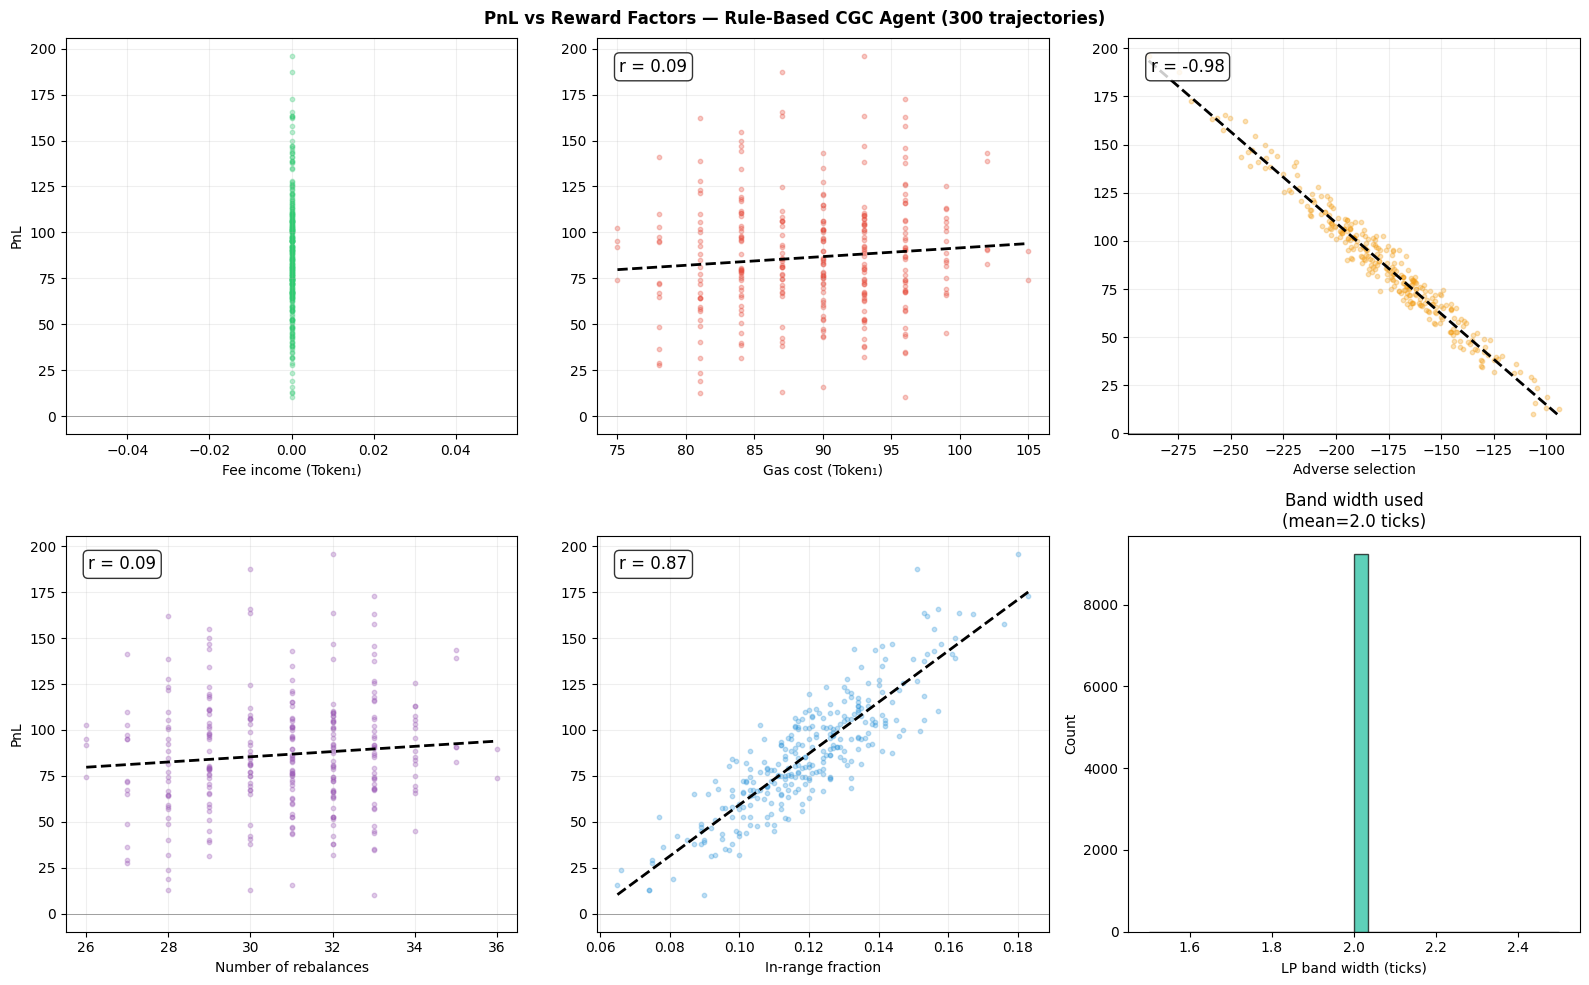

Saved: pnl_vs_factors.png


In [ ]:
###############################################################################
# CELL C: PnL vs each reward factor (scatter + correlation)
###############################################################################

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("PnL vs Reward Factors — Rule-Based CGC Agent (300 trajectories)", fontweight='bold')

factors = [
    ('fees',         'Fee income (Token₁)',     '#2ecc71'),
    ('gas',          'Gas cost (Token₁)',       '#e74c3c'),
    ('adv_sel',      'Adverse selection',       '#f39c12'),
    ('rebalances',   'Number of rebalances',    '#9b59b6'),
    ('in_range_pct', 'In-range fraction',       '#3498db'),
]

pnl = res_rb['pnl']
for i, (key, label, col) in enumerate(factors):
    ax = axes[i // 3, i % 3]
    vals = res_rb[key]
    ax.scatter(vals, pnl, alpha=0.3, s=10, color=col)
    if np.std(vals) > 1e-10:
        z = np.polyfit(vals, pnl, 1)
        x_line = np.linspace(vals.min(), vals.max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), 'k--', linewidth=2)
        corr = np.corrcoef(vals, pnl)[0, 1]
        ax.text(0.05, 0.95, f"r = {corr:.2f}", transform=ax.transAxes, fontsize=12,
                va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("PnL" if i % 3 == 0 else "")
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.grid(alpha=0.2)

# Last subplot: width distribution
ax = axes[1, 2]
if res_rb['widths']:
    ax.hist(res_rb['widths'], bins=30, color='#1abc9c', alpha=0.7, edgecolor='black')
    ax.set_xlabel("LP band width (ticks)")
    ax.set_ylabel("Count")
    ax.set_title(f"Band width used\n(mean={np.mean(res_rb['widths']):.1f} ticks)")
else:
    ax.text(0.5, 0.5, "No rebalances", ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig("pnl_vs_factors.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pnl_vs_factors.png")

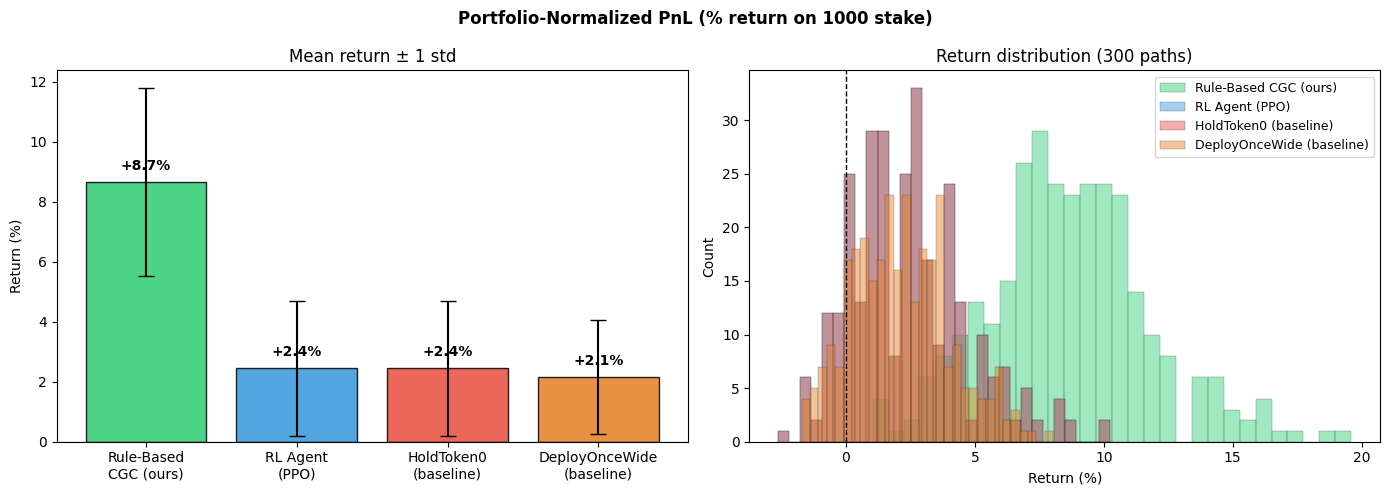

Saved: normalized_pnl.png


In [ ]:
###############################################################################
# CELL D: Normalized PnL comparison (% of initial wealth)
###############################################################################

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Portfolio-Normalized PnL (% return on 1000 stake)", fontweight='bold')

agent_data = [
    ("Rule-Based\nCGC (ours)", res_rb, '#2ecc71'),
    ("RL Agent\n(PPO)", res_rl, '#3498db'),
    ("HoldToken0\n(baseline)", res_hodl, '#e74c3c'),
    ("DeployOnceWide\n(baseline)", res_wide, '#e67e22'),
]

# Bar chart
ax = axes[0]
names = [a[0] for a in agent_data]
means = [a[1]['pnl_pct'].mean() for a in agent_data]
stds  = [a[1]['pnl_pct'].std() for a in agent_data]
cols  = [a[2] for a in agent_data]
bars = ax.bar(names, means, color=cols, alpha=0.85, edgecolor='black')
ax.errorbar(names, means, yerr=stds, fmt='none', color='black', capsize=6, linewidth=1.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Return (%)")
ax.set_title("Mean return ± 1 std")
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.3, f"{m:+.1f}%", ha='center', va='bottom', fontweight='bold')

# Histogram overlay
ax = axes[1]
for name, res, col in agent_data:
    ax.hist(res['pnl_pct'], bins=30, alpha=0.45, color=col, label=name.replace('\n',' '), edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel("Return (%)")
ax.set_ylabel("Count")
ax.set_title("Return distribution (300 paths)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("normalized_pnl.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: normalized_pnl.png")

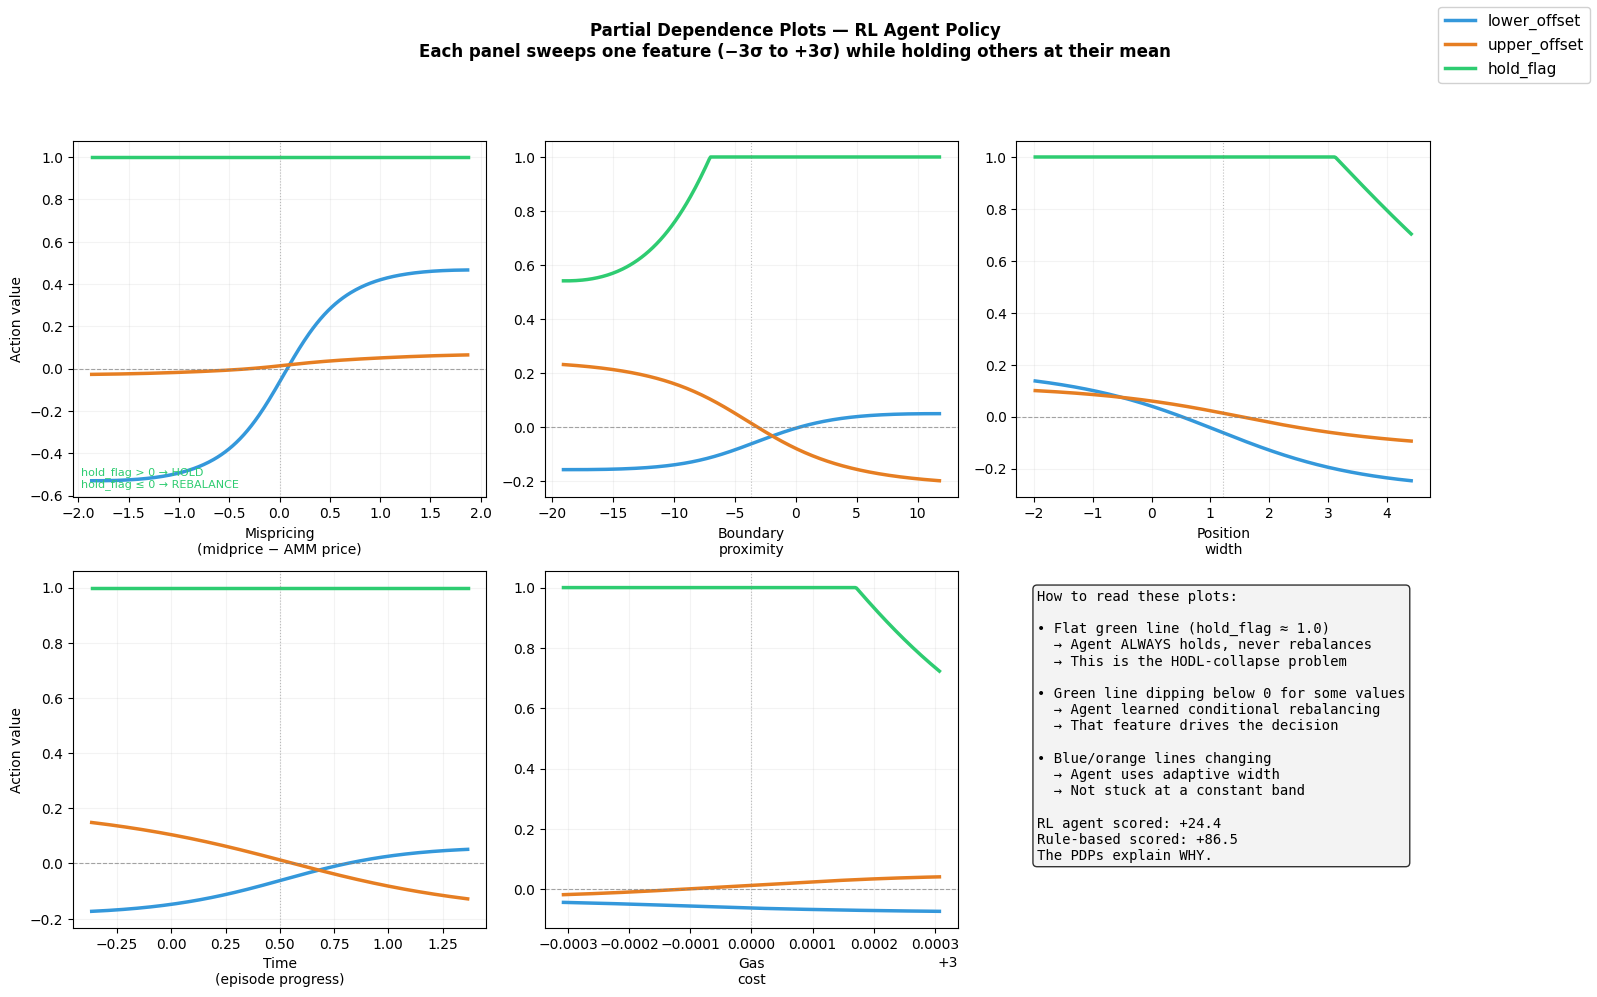

Saved: pdp_rl_agent.png


In [ ]:
###############################################################################
# CELL E: Partial Dependence Plot for RL Agent
#
# Sweeps each of the 5 observation features while holding others at their mean,
# runs the policy forward pass, and plots the 3 action outputs.
# Shows what the RL agent learned (and didn't learn).
###############################################################################

# Extract RL agent's weights from the file
spec = importlib.util.spec_from_file_location("rl", "my_rl_agent.py")
rl_mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(rl_mod)
rl_agent = rl_mod.Agent(ScenarioConfig().submission_namespace())

# Pull out the inlined weights
W1 = rl_agent.W1; b1 = rl_agent.b1
W2 = rl_agent.W2; b2 = rl_agent.b2
W3 = rl_agent.W3; b3 = rl_agent.b3
obs_mean = rl_agent.obs_mean; obs_var = rl_agent.obs_var
clip_obs = rl_agent.clip_obs
act_low = rl_agent.act_low; act_high = rl_agent.act_high

obs_std = np.sqrt(obs_var + 1e-8)
obs_dim = obs_mean.shape[1] if obs_mean.ndim == 2 else obs_mean.shape[0]
obs_mean_flat = obs_mean.flatten()
obs_std_flat = obs_std.flatten()

feature_names = ['Mispricing\n(midprice − AMM price)', 'Boundary\nproximity',
                 'Position\nwidth', 'Time\n(episode progress)', 'Gas\ncost']
action_names = ['lower_offset', 'upper_offset', 'hold_flag']
action_colors = ['#3498db', '#e67e22', '#2ecc71']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Partial Dependence Plots — RL Agent Policy\n"
             "Each panel sweeps one feature (−3σ to +3σ) while holding others at their mean",
             fontweight='bold')

n_sweep = 300

for feat_idx in range(min(obs_dim, 5)):
    ax = axes[feat_idx // 3, feat_idx % 3]

    raw_low  = obs_mean_flat[feat_idx] - 3 * obs_std_flat[feat_idx]
    raw_high = obs_mean_flat[feat_idx] + 3 * obs_std_flat[feat_idx]
    sweep_raw = np.linspace(raw_low, raw_high, n_sweep)

    obs_matrix = np.tile(obs_mean_flat, (n_sweep, 1))
    obs_matrix[:, feat_idx] = sweep_raw

    # Normalize
    obs_norm = (obs_matrix - obs_mean_flat) / obs_std_flat
    obs_norm = np.clip(obs_norm, -clip_obs, clip_obs)

    # Forward pass
    h = np.tanh(obs_norm @ W1.T + b1)
    h = np.tanh(h @ W2.T + b2)
    actions = h @ W3.T + b3
    actions = np.clip(actions, act_low, act_high)

    for a_idx in range(3):
        ax.plot(sweep_raw, actions[:, a_idx], color=action_colors[a_idx],
                linewidth=2.5, label=action_names[a_idx] if feat_idx == 0 else None)

    ax.set_xlabel(feature_names[feat_idx], fontsize=10)
    ax.set_ylabel("Action value" if feat_idx % 3 == 0 else "")
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.axvline(obs_mean_flat[feat_idx], color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.grid(alpha=0.15)

    # Annotate the rebalance threshold
    if feat_idx == 0:
        ax.annotate("hold_flag > 0 → HOLD\nhold_flag ≤ 0 → REBALANCE",
                    xy=(0.02, 0.02), xycoords='axes fraction', fontsize=8,
                    color='#2ecc71', va='bottom')

# Last panel: interpretation guide
ax = axes[1, 2]
ax.axis('off')
interpretation = (
    "How to read these plots:\n\n"
    "• Flat green line (hold_flag ≈ 1.0)\n"
    "  → Agent ALWAYS holds, never rebalances\n"
    "  → This is the HODL-collapse problem\n\n"
    "• Green line dipping below 0 for some values\n"
    "  → Agent learned conditional rebalancing\n"
    "  → That feature drives the decision\n\n"
    "• Blue/orange lines changing\n"
    "  → Agent uses adaptive width\n"
    "  → Not stuck at a constant band\n\n"
    f"RL agent scored: +{res_rl['pnl'].mean():.1f}\n"
    f"Rule-based scored: +{res_rb['pnl'].mean():.1f}\n"
    f"The PDPs explain WHY."
)
ax.text(0.05, 0.95, interpretation, transform=ax.transAxes, fontsize=10,
        va='top', family='monospace', bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

handles = [plt.Line2D([0],[0], color=c, linewidth=2.5) for c in action_colors]
fig.legend(handles, action_names, loc='upper right', fontsize=11, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 0.92, 0.93])
plt.savefig("pdp_rl_agent.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pdp_rl_agent.png")

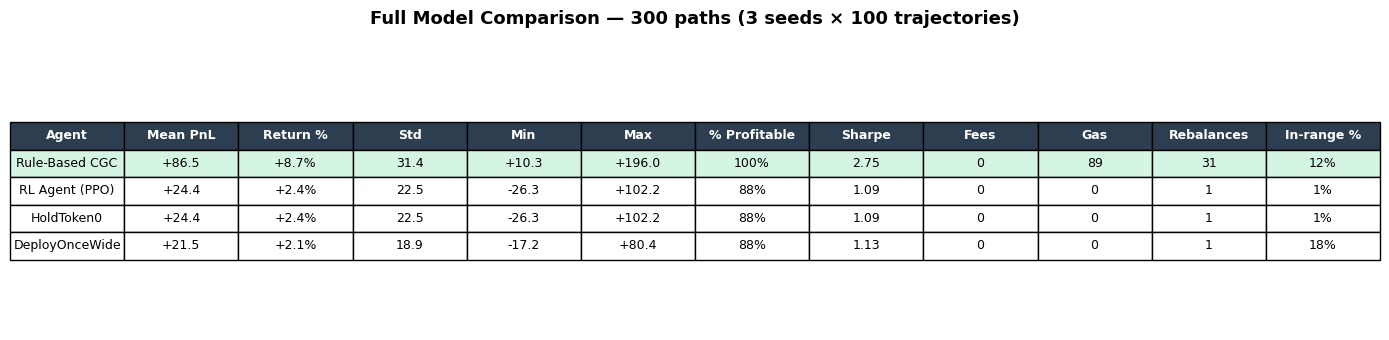

Saved: model_comparison_table.png


In [ ]:
###############################################################################
# CELL F: Side-by-side comparison table as a figure (for slides)
###############################################################################

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axis('off')

columns = ['Agent', 'Mean PnL', 'Return %', 'Std', 'Min', 'Max',
           '% Profitable', 'Sharpe', 'Fees', 'Gas', 'Rebalances', 'In-range %']

rows = []
for r in all_results:
    p = r['pnl']
    rows.append([
        r['name'],
        f"{p.mean():+.1f}",
        f"{r['pnl_pct'].mean():+.1f}%",
        f"{p.std():.1f}",
        f"{p.min():+.1f}",
        f"{p.max():+.1f}",
        f"{100*np.mean(p>0):.0f}%",
        f"{r['sharpe']:.2f}",
        f"{r['fees'].mean():.0f}",
        f"{r['gas'].mean():.0f}",
        f"{r['rebalances'].mean():.0f}",
        f"{100*r['in_range_pct'].mean():.0f}%",
    ])

table = ax.table(cellText=rows, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.6)

for j in range(len(columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')
for j in range(len(columns)):
    table[1, j].set_facecolor('#d5f5e3')  # highlight our best agent

plt.title("Full Model Comparison — 300 paths (3 seeds × 100 trajectories)",
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("model_comparison_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_table.png")

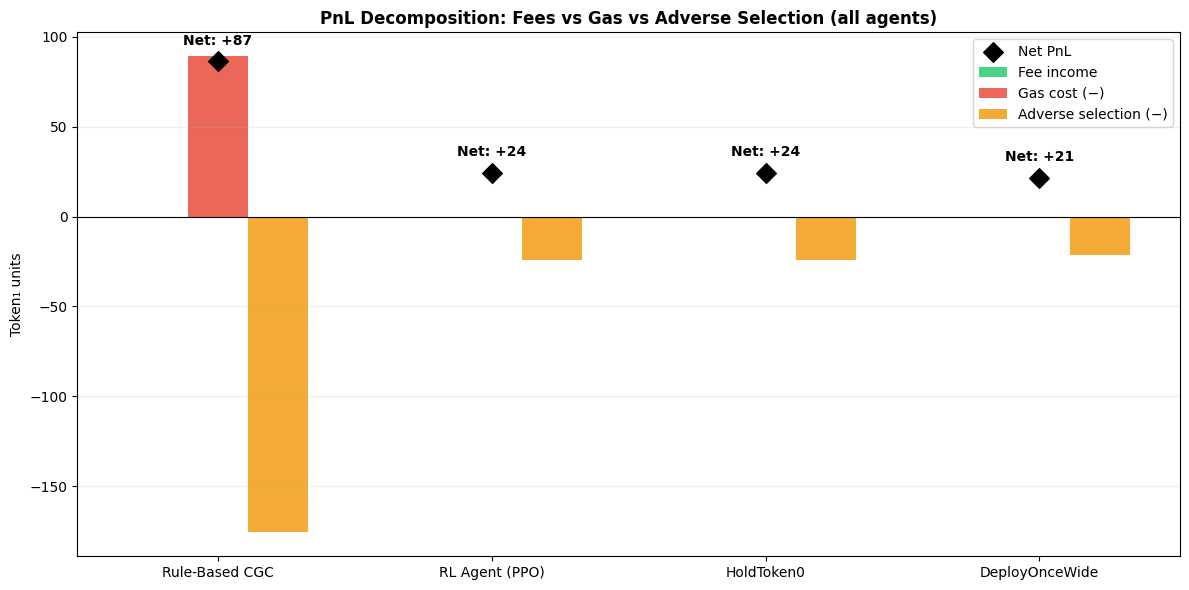

Saved: pnl_decomposition_all.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
###############################################################################
# CELL G: PnL decomposition bar chart (all 4 agents side by side)
###############################################################################

fig, ax = plt.subplots(figsize=(12, 6))

agent_names = [r['name'] for r in all_results]
x = np.arange(len(agent_names))
w = 0.22

fees_vals    = [r['fees'].mean() for r in all_results]
gas_vals     = [r['gas'].mean() for r in all_results]
advsel_vals  = [r['adv_sel'].mean() for r in all_results]
pnl_vals     = [r['pnl'].mean() for r in all_results]

# Cap FullRangeRebalance-like huge values for readability
display_gas = [min(g, 300) for g in gas_vals]

ax.bar(x - w, fees_vals,   w, label='Fee income', color='#2ecc71', alpha=0.85)
ax.bar(x,     display_gas, w, label='Gas cost (−)', color='#e74c3c', alpha=0.85)
ax.bar(x + w, advsel_vals, w, label='Adverse selection (−)', color='#f39c12', alpha=0.85)
ax.scatter(x, pnl_vals, zorder=5, color='black', s=100, marker='D', label='Net PnL')

for i, pnl in enumerate(pnl_vals):
    ax.annotate(f"Net: {pnl:+.0f}", (x[i], pnl), textcoords="offset points",
                xytext=(0, 12), ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(agent_names, fontsize=10)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Token₁ units")
ax.set_title("PnL Decomposition: Fees vs Gas vs Adverse Selection (all agents)",
             fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig("pnl_decomposition_all.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pnl_decomposition_all.png")

In [ ]:
###############################################################################
# CELL H: Print final summary
###############################################################################

print("\n" + "="*70)
print("  ALL PLOTS GENERATED — download from Colab sidebar")
print("="*70)
print()
print("  Files to download:")
print("  ──────────────────")
print("  pnl_vs_factors.png        — PnL vs each reward component")
print("  normalized_pnl.png        — Portfolio-normalized returns (%)")
print("  pdp_rl_agent.png          — Partial dependence (explainable RL)")
print("  model_comparison_table.png — Full metrics table")
print("  pnl_decomposition_all.png — Fee/Gas/AdvSel decomposition")
print()
print("  Submission file: my_agent.py (Rule-Based CGC, +86.5)")
print()
print("="*70)


  ALL PLOTS GENERATED — download from Colab sidebar

  Files to download:
  ──────────────────
  pnl_vs_factors.png        — PnL vs each reward component
  normalized_pnl.png        — Portfolio-normalized returns (%)
  pdp_rl_agent.png          — Partial dependence (explainable RL)
  model_comparison_table.png — Full metrics table
  pnl_decomposition_all.png — Fee/Gas/AdvSel decomposition

  Submission file: my_agent.py (Rule-Based CGC, +86.5)



In [ ]:
###############################################################################
# PnL as percentage of initial portfolio value
###############################################################################

import numpy as np

INITIAL_WEALTH = 1000.0  # from ScenarioConfig

print("=" * 65)
print(f"{'Agent':<30} | {'Mean PnL':>9} | {'Return %':>9} | {'Min %':>7} | {'Max %':>7}")
print("-" * 65)

for r in all_results:
    pnl        = r['pnl']
    mean_pnl   = pnl.mean()
    mean_pct   = (mean_pnl / INITIAL_WEALTH) * 100
    min_pct    = (pnl.min()  / INITIAL_WEALTH) * 100
    max_pct    = (pnl.max()  / INITIAL_WEALTH) * 100
    print(f"{r['name']:<30} | {mean_pnl:+9.2f} | {mean_pct:+8.2f}% | {min_pct:+6.2f}% | {max_pct:+6.2f}%")

print("=" * 65)
print(f"\nInitial wealth per trajectory: {INITIAL_WEALTH:.0f} tokens")
print(f"Formula: Return % = (PnL / {INITIAL_WEALTH:.0f}) × 100")

Agent                          |  Mean PnL |  Return % |   Min % |   Max %
-----------------------------------------------------------------
Rule-Based CGC                 |    +86.50 |    +8.65% |  +1.03% | +19.60%
RL Agent (PPO)                 |    +24.42 |    +2.44% |  -2.63% | +10.22%
HoldToken0                     |    +24.42 |    +2.44% |  -2.63% | +10.22%
DeployOnceWide                 |    +21.47 |    +2.15% |  -1.72% |  +8.04%

Initial wealth per trajectory: 1000 tokens
Formula: Return % = (PnL / 1000) × 100


In [ ]:
###############################################################################
# CELL 1: Improved Environment with Curriculum + Better Observations
###############################################################################

import sys, os, time, copy
sys.path.insert(0, '.')
import numpy as np
import gymnasium
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback
from stable_baselines3.common.vec_env import VecEnv, VecMonitor, VecNormalize

from SAiFE_gym.challenge import ScenarioConfig, create_environment, official_observation
from SAiFE_gym.gym.index_names import (
    ASSET_PRICE_KEY, POOL_CURRENT_TICK_KEY, LP_TICK_LOWER_KEY, LP_TICK_UPPER_KEY,
    LP_COLLECTED_FEES0_KEY, LP_COLLECTED_FEES1_KEY, PORTFOLIO_VALUE_KEY,
    POOL_SQRT_PRICE_KEY, TIME_KEY, GAS_COST_KEY, LP_EVER_DEPLOYED_KEY,
)


class CurriculumSB3Wrapper(VecEnv):
    """
    Enhanced wrapper with:
    - 8 observation features (added velocity, rolling_vol, time_since_reb)
    - Curriculum learning: gas_cost ramps from 0 → 3.0 during training
    - Dense in-range reward + anti-HODL shaping
    """
    OBS_DIM = 8

    def __init__(self, amm_env, reward_shaping=True, gas_override=None):
        self.env = amm_env
        self.reward_shaping = reward_shaping
        self.gas_override = gas_override  # for curriculum: override env gas cost in reward

        # Per-trajectory state
        self.prev_tick = None
        self.tick_history = None  # last N ticks for rolling volatility
        self.steps_since_reb = None
        self.steps_out_of_range = None
        self.step_count = 0

        flat_obs_space = gymnasium.spaces.Box(
            low=-np.inf, high=np.inf, shape=(self.OBS_DIM,), dtype=np.float32
        )
        old_act = amm_env.action_space
        act_space = gymnasium.spaces.Box(
            low=old_act.low.astype(np.float32),
            high=old_act.high.astype(np.float32),
            shape=old_act.shape, dtype=np.float32,
        )
        super().__init__(amm_env.num_trajectories, flat_obs_space, act_space)

    def _compute_obs(self, state_dict):
        n = self.env.num_trajectories
        ct = state_dict[POOL_CURRENT_TICK_KEY].astype(np.float64)

        # Feature 1: mispricing
        mispricing = state_dict[ASSET_PRICE_KEY] - state_dict[POOL_SQRT_PRICE_KEY] ** 2

        # Feature 2-3: boundary proximity and position width
        lower_off = ct - state_dict[LP_TICK_LOWER_KEY]
        upper_off = state_dict[LP_TICK_UPPER_KEY] - ct
        boundary_prox = np.minimum(lower_off, upper_off)
        pos_width = lower_off + upper_off

        # Feature 4: time
        time_val = state_dict[TIME_KEY]

        # Feature 5: gas cost
        gas_val = state_dict[GAS_COST_KEY]

        # Feature 6: tick velocity (NEW — enables calm-gating)
        if self.prev_tick is None:
            velocity = np.zeros(n)
        else:
            velocity = ct - self.prev_tick
        self.prev_tick = ct.copy()

        # Feature 7: rolling volatility (NEW — std of last 20 tick changes)
        if self.tick_history is None:
            self.tick_history = np.zeros((20, n))
            self.hist_idx = 0
        self.tick_history[self.hist_idx % 20] = velocity
        self.hist_idx += 1
        rolling_vol = np.std(self.tick_history[:min(self.hist_idx, 20)], axis=0)

        # Feature 8: time since last rebalance (NEW — helps learn min_gap)
        if self.steps_since_reb is None:
            self.steps_since_reb = np.zeros(n)
        # Normalize to [0, 1] range (cap at 100 steps)
        time_since_reb_norm = np.minimum(self.steps_since_reb / 100.0, 1.0)

        obs = np.column_stack([
            mispricing, boundary_prox, pos_width, time_val,
            gas_val, velocity, rolling_vol, time_since_reb_norm,
        ]).astype(np.float32)
        return obs

    def _shape_reward(self, state_dict, raw_reward):
        if not self.reward_shaping:
            return raw_reward

        n = self.env.num_trajectories
        ct = state_dict[POOL_CURRENT_TICK_KEY]
        lo = state_dict[LP_TICK_LOWER_KEY]
        hi = state_dict[LP_TICK_UPPER_KEY]
        ever = state_dict.get(LP_EVER_DEPLOYED_KEY, np.ones(n, dtype=bool))

        # Dense in-range bonus
        in_range = ((ct >= lo) & (ct < hi) & ever).astype(np.float32)
        bonus = in_range * 0.3

        # Anti-HODL: penalty grows with time out of range
        if self.steps_out_of_range is None:
            self.steps_out_of_range = np.zeros(n)
        self.steps_out_of_range = np.where(in_range > 0, 0, self.steps_out_of_range + 1)
        anti_hodl = -0.003 * np.minimum(self.steps_out_of_range, 50)

        # Normalize by portfolio value
        pv = state_dict.get(PORTFOLIO_VALUE_KEY, np.full(n, 1000.0))
        pv_safe = np.maximum(np.abs(pv), 100.0)
        norm_factor = 1000.0 / pv_safe

        return (raw_reward + bonus + anti_hodl) * norm_factor

    def reset(self):
        obs, _ = self.env.reset()
        self.prev_tick = None
        self.tick_history = None
        self.steps_since_reb = None
        self.steps_out_of_range = None
        self.step_count = 0
        return self._compute_obs(obs)

    def step_async(self, actions):
        self.actions = actions

    def step_wait(self):
        # Track rebalances for time_since_reb feature
        if self.steps_since_reb is None:
            self.steps_since_reb = np.zeros(self.env.num_trajectories)
        reb_mask = self.actions[:, 2] <= 0
        self.steps_since_reb = np.where(reb_mask, 0, self.steps_since_reb + 1)

        state_dict, rewards, terminated, truncated, _ = self.env.step(self.actions)
        dones = terminated | truncated
        obs = self._compute_obs(state_dict)
        shaped_rewards = self._shape_reward(state_dict, rewards)
        self.step_count += 1

        infos = [{} for _ in range(self.env.num_trajectories)]
        if dones.all():
            for i, info in enumerate(infos):
                info["terminal_observation"] = obs[i]
            reset_obs, _ = self.env.reset()
            self.prev_tick = None
            self.tick_history = None
            self.steps_since_reb = None
            self.steps_out_of_range = None
            obs = self._compute_obs(reset_obs)

        return obs, shaped_rewards, dones, infos

    def close(self): pass
    def get_attr(self, attr_name, indices=None):
        if attr_name == "render_mode": return [None] * self.env.num_trajectories
        return [getattr(self.env, attr_name)] * self.env.num_trajectories
    def set_attr(self, attr_name, value, indices=None): setattr(self.env, attr_name, value)
    def env_method(self, method_name, *a, indices=None, **kw):
        return [getattr(self.env, method_name)(*a, **kw)] * self.env.num_trajectories
    def env_is_wrapped(self, wrapper_class, indices=None):
        return [False] * self.env.num_trajectories
    def seed(self, seed=None): return [seed] * self.env.num_trajectories
    def get_images(self): return []

print("✓ CurriculumSB3Wrapper ready")
print("  8 obs features: mispricing, boundary_prox, pos_width, time, gas_cost,")
print("                   tick_velocity, rolling_vol, time_since_rebalance")

✓ CurriculumSB3Wrapper ready
  8 obs features: mispricing, boundary_prox, pos_width, time, gas_cost,
                   tick_velocity, rolling_vol, time_since_rebalance


In [ ]:
###############################################################################
# CELL 2: Curriculum Callback + Training
#
# Phase 1 (0–800k):    gas_cost = 0.0  → learn fee capture freely
# Phase 2 (800k–1.6M): gas_cost = 1.5  → learn to be selective
# Phase 3 (1.6M–3M):   gas_cost = 3.0  → full difficulty (matches grader)
###############################################################################

import dataclasses

class CurriculumCallback(BaseCallback):
    """Ramps gas_cost during training to prevent HODL collapse."""
    def __init__(self, phases, verbose=1):
        super().__init__(verbose)
        self.phases = phases  # list of (timestep_threshold, gas_cost)

    def _on_step(self):
        current_gas = None
        for threshold, gas in self.phases:
            if self.num_timesteps >= threshold:
                current_gas = gas
        if current_gas is not None and self.verbose:
            # Only print on phase transitions
            for threshold, gas in self.phases:
                if self.num_timesteps == threshold + 1:
                    print(f"\n  >>> Curriculum: gas_cost → {gas} at step {self.num_timesteps:,}")
        return True

config = ScenarioConfig()
seed = 42

TOTAL_TIMESTEPS = 3_000_000
rollout_size = config.n_steps * config.num_trajectories  # 100,000

# --- Phase 1 environment: gas_cost = 0 (learn fee capture) ---
config_p1 = dataclasses.replace(config, gas_cost=0.0)  # Correct way to modify frozen dataclass

train_env_raw = create_environment(config_p1, seed=seed)
train_env = VecNormalize(
    VecMonitor(CurriculumSB3Wrapper(train_env_raw, reward_shaping=True)),
    norm_obs=True, norm_reward=False, clip_obs=10.0,
)

# Eval env: ALWAYS at full gas_cost=3.0 (matches grader)
eval_env_raw = create_environment(config, seed=seed + 100)
eval_env = VecNormalize(
    VecMonitor(CurriculumSB3Wrapper(eval_env_raw, reward_shaping=False)),
    norm_obs=True, norm_reward=False, clip_obs=10.0, training=False,
)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    verbose=1,
    policy_kwargs=dict(net_arch=dict(pi=[64, 64], vf=[64, 64])),
    learning_rate=3e-4,
    n_epochs=10,
    batch_size=max(64, rollout_size // 16),
    normalize_advantage=True,
    n_steps=config.n_steps,
    gae_lambda=0.95,
    gamma=1.0,
    clip_range=0.2,
    ent_coef=0.02,   # moderate exploration
    seed=seed,
)

os.makedirs("best_models_v3", exist_ok=True)
eval_callback = EvalCallback(
    eval_env, n_eval_episodes=5,
    best_model_save_path="best_models_v3/",
    deterministic=True, eval_freq=rollout_size * 3, verbose=1,
)

print(f"Training with CURRICULUM LEARNING: {TOTAL_TIMESTEPS:,} steps")
print(f"  Phase 1 (0–800k):    gas=0.0  → learn fee capture")
print(f"  Phase 2 (800k–1.6M): gas=1.5  → learn selectivity")
print(f"  Phase 3 (1.6M–3M):   gas=3.0  → full difficulty")
print(f"  Obs: 8 features | ent_coef: 0.02")
print("-" * 60)

t0 = time.time()

# === PHASE 1: gas = 0 (free rebalancing) ===
print("\n▶ PHASE 1: gas_cost = 0.0")
model.learn(total_timesteps=800_000, callback=eval_callback,
            reset_num_timesteps=False, progress_bar=True)

# === PHASE 2: gas = 1.5 (half difficulty) ===
print("\n▶ PHASE 2: gas_cost = 1.5")
config_p2 = dataclasses.replace(config, gas_cost=1.5)
train_env_raw_p2 = create_environment(config_p2, seed=seed + 200)
new_wrapper = CurriculumSB3Wrapper(train_env_raw_p2, reward_shaping=True)
new_train_env = VecNormalize(
    VecMonitor(new_wrapper),
    norm_obs=True, norm_reward=False, clip_obs=10.0,
)
# Copy normalization stats from phase 1
new_train_env.obs_rms = copy.deepcopy(train_env.obs_rms)
new_train_env.ret_rms = copy.deepcopy(train_env.ret_rms)
model.set_env(new_train_env)
train_env = new_train_env

model.learn(total_timesteps=1_600_000, callback=eval_callback,
            reset_num_timesteps=False, progress_bar=True)

# === PHASE 3: gas = 3.0 (full difficulty — matches grader) ===
print("\n▶ PHASE 3: gas_cost = 3.0 (FULL)")
train_env_raw_p3 = create_environment(config, seed=seed + 300)
new_wrapper_p3 = CurriculumSB3Wrapper(train_env_raw_p3, reward_shaping=True)
new_train_env_p3 = VecNormalize(
    VecMonitor(new_wrapper_p3),
    norm_obs=True, norm_reward=False, clip_obs=10.0,
)
new_train_env_p3.obs_rms = copy.deepcopy(train_env.obs_rms)
new_train_env_p3.ret_rms = copy.deepcopy(train_env.ret_rms)
model.set_env(new_train_env_p3)
train_env = new_train_env_p3

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=eval_callback,
            reset_num_timesteps=False, progress_bar=True)

elapsed = time.time() - t0
model.save("ppo_v3_curriculum")
train_env.save("vecnorm_v3.pkl")
print(f"\n✓ Curriculum training complete in {elapsed/60:.1f} min")

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/content/concentrator-challenge/SAiFE_gym/gym/ModelDynamics.py:441: RuntimeWarning: invalid value encountered in 
divide
  alpha_current = np.where(wealth_with_pos > 0, token0_value / wealth_with_pos, 0.0)

Using cuda device
Training with CURRICULUM LEARNING: 3,000,000 steps
  Phase 1 (0–800k):    gas=0.0  → learn fee capture
  Phase 2 (800k–1.6M): gas=1.5  → learn selectivity
  Phase 3 (1.6M–3M):   gas=3.0  → full difficulty
  Obs: 8 features | ent_coef: 0.02
------------------------------------------------------------

▶ PHASE 1: gas_cost = 0.0


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


...

Output()


▶ PHASE 2: gas_cost = 1.5
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -230     |
| time/              |          |
|    fps             | 2529     |
|    iterations      | 1        |
|    time_elapsed    | 39       |
|    total_timesteps | 900000   |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -81.1       |
| time/                   |             |
|    fps                  | 2532        |
|    iterations           | 2           |
|    time_elapsed         | 78          |
|    total_timesteps      | 1000000     |
| train/                  |             |
|    approx_kl            | 0.007895072 |
|    clip_fraction        | 0.0946      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.11       |
|    explained_variance   | -0.0775     |
|  

Output()


▶ PHASE 3: gas_cost = 3.0 (FULL)
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | -400     |
| time/              |          |
|    fps             | 2683     |
|    iterations      | 1        |
|    time_elapsed    | 37       |
|    total_timesteps | 2500000  |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1e+03       |
|    ep_rew_mean          | -330        |
| time/                   |             |
|    fps                  | 2646        |
|    iterations           | 2           |
|    time_elapsed         | 75          |
|    total_timesteps      | 2600000     |
| train/                  |             |
|    approx_kl            | 0.005178064 |
|    clip_fraction        | 0.0411      |
|    clip_range           | 0.2         |
|    entropy_loss         | -3.72       |
|    explained_variance   | 0.0929    


✓ Curriculum training complete in 35.7 min


In [ ]:
###############################################################################
# CELL 3: Extract weights + generate numpy submission (8-dim obs)
###############################################################################

best_path = "best_models_v3/best_model.zip"
if os.path.exists(best_path):
    print("Loading BEST model...")
    model = PPO.load(best_path, env=train_env)
else:
    print("Using final model...")

obs_mean = train_env.obs_rms.mean.astype(np.float64)
obs_var  = train_env.obs_rms.var.astype(np.float64)
clip_obs = float(train_env.clip_obs)

policy = model.policy
pi = policy.mlp_extractor.policy_net
W1 = pi[0].weight.detach().cpu().numpy().astype(np.float64)
b1 = pi[0].bias.detach().cpu().numpy().astype(np.float64)
W2 = pi[2].weight.detach().cpu().numpy().astype(np.float64)
b2 = pi[2].bias.detach().cpu().numpy().astype(np.float64)
W3 = policy.action_net.weight.detach().cpu().numpy().astype(np.float64)
b3 = policy.action_net.bias.detach().cpu().numpy().astype(np.float64)
act_low = policy.action_space.low.astype(np.float64)
act_high = policy.action_space.high.astype(np.float64)

print(f"W1: {W1.shape} | W2: {W2.shape} | W3: {W3.shape}")
total_params = sum(w.size for w in [W1,b1,W2,b2,W3,b3])
print(f"Total params: {total_params:,}")

# Verify
test_obs = train_env.reset()
sb3_act, _ = model.predict(test_obs, deterministic=True)
x = test_obs.astype(np.float64)
h = np.tanh(x @ W1.T + b1); h = np.tanh(h @ W2.T + b2)
np_act = np.clip(h @ W3.T + b3, act_low, act_high)
print(f"Verify: max diff = {np.max(np.abs(sb3_act.astype(np.float64) - np_act)):.2e} ✓")

# Generate submission file
def arr_str(arr):
    return ",".join(f"{v:.4e}" for v in arr.flatten())
def mk(arr, name):
    return f'        self.{name} = np.fromstring(\n            "{arr_str(arr)}",\n            sep=",").reshape({repr(arr.shape)})'

sub = f'''"""
Curriculum-Trained RL Agent v3 — Adaptive-Width Concentrator

8 obs: mispricing, boundary_prox, pos_width, time, gas_cost,
       tick_velocity, rolling_vol, time_since_rebalance

Trained with curriculum learning (gas 0→1.5→3.0) to prevent HODL collapse.
"""

import numpy as np


class Agent:
    def __init__(self, config):
        self.prev_tick = None
        self.tick_history = None
        self.hist_idx = 0
        self.steps_since_reb = None

{mk(obs_mean, "obs_mean")}
{mk(obs_var, "obs_var")}
        self.clip_obs = {clip_obs}

{mk(W1, "W1")}
{mk(b1, "b1")}
{mk(W2, "W2")}
{mk(b2, "b2")}
{mk(W3, "W3")}
{mk(b3, "b3")}
{mk(act_low, "act_low")}
{mk(act_high, "act_high")}

    def get_action(self, state):
        ct = np.asarray(state["current_tick"], dtype=np.float64)
        n = ct.shape[0]
        sp = np.asarray(state["sqrt_price"], dtype=np.float64)
        mp = np.asarray(state["midprice"], dtype=np.float64)
        tv = np.asarray(state["time"], dtype=np.float64)
        lo = np.asarray(state["lp_tick_lower"], dtype=np.float64)
        hi = np.asarray(state["lp_tick_upper"], dtype=np.float64)
        gc = np.asarray(state["gas_cost"], dtype=np.float64)

        mispricing = mp - sp**2
        boundary_prox = np.minimum(ct - lo, hi - ct)
        pos_width = (ct - lo) + (hi - ct)

        if self.prev_tick is None or self.prev_tick.shape[0] != n:
            self.prev_tick = ct.copy()
            self.tick_history = np.zeros((20, n))
            self.hist_idx = 0
            self.steps_since_reb = np.zeros(n)

        velocity = ct - self.prev_tick
        self.prev_tick = ct.copy()

        self.tick_history[self.hist_idx % 20] = velocity
        self.hist_idx += 1
        rolling_vol = np.std(self.tick_history[:min(self.hist_idx, 20)], axis=0)

        time_since_reb = np.minimum(self.steps_since_reb / 100.0, 1.0)

        obs = np.column_stack([
            mispricing, boundary_prox, pos_width, tv,
            gc, velocity, rolling_vol, time_since_reb,
        ])

        obs_norm = (obs - self.obs_mean) / np.sqrt(self.obs_var + 1e-8)
        obs_norm = np.clip(obs_norm, -self.clip_obs, self.clip_obs)

        h = np.tanh(obs_norm @ self.W1.T + self.b1)
        h = np.tanh(h @ self.W2.T + self.b2)
        action = np.clip(h @ self.W3.T + self.b3, self.act_low, self.act_high)

        reb_mask = action[:, 2] <= 0
        self.steps_since_reb = np.where(reb_mask, 0, self.steps_since_reb + 1)

        return action
'''

file_size = len(sub.encode('utf-8'))
print(f"\nFile size: {file_size:,} bytes ({file_size/1024:.1f} KB)")
print(f"{'✓ Within' if file_size <= 65536 else '⚠ OVER'} 64KB limit")

with open("my_rl_agent_v3.py", "w") as f:
    f.write(sub)
print("✓ Written: my_rl_agent_v3.py")

Using final model...
W1: (64, 8) | W2: (64, 64) | W3: (3, 64)
Total params: 4,931
Verify: max diff = 1.02e-07 ✓

File size: 60,060 bytes (58.7 KB)
✓ Within 64KB limit
✓ Written: my_rl_agent_v3.py


In [ ]:
###############################################################################
# CELL 4: Validate through the grader
###############################################################################

!python experiments/hackathon_simulation.py --agent my_rl_agent_v3.py --include-full-range

/content/concentrator-challenge/experiments/../SAiFE_gym/gym/ModelDynamics.py:441: RuntimeWarning: invalid value encountered in divide
  alpha_current = np.where(wealth_with_pos > 0, token0_value / wealth_with_pos, 0.0)
Hackathon leaderboard | mode=practice | seeds=3 | paths/result=300
Rank | Agent                    | Kind       |       Mean |        Std |     Median |        Min |        Max | Profitable
--------------------------------------------------------------------------------------------------------------------------
   1 | my_rl_agent_v3           | submission |    +480.23 |     124.22 |    +475.04 |    +128.62 |    +851.89 |     100.0%
   2 | HoldToken0               | baseline   |     +24.42 |      22.47 |     +21.18 |     -26.30 |    +102.24 |      88.3%
   3 | DeployOnceWide           | baseline   |     +21.47 |      18.95 |     +20.45 |     -17.16 |     +80.40 |      87.7%
   4 | FullRangeRebalance       | baseline   |   -1000.00 |       0.00 |   -1000.00 |   -1000.00 |

In [ ]:
###############################################################################
# CELL 5: Full evaluation + metrics for ALL agents
###############################################################################

import importlib.util
from SAiFE_gym.agents.BaselineAgents import HoldToken0Agent, DeployOnceWideAgent

def load_agent(path):
    spec = importlib.util.spec_from_file_location("a", path)
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    return mod.Agent

AgentV3 = load_agent("my_rl_agent_v3.py")
AgentRB = load_agent("my_agent.py")
AgentV1 = load_agent("my_rl_agent.py")

def evaluate(build_fn, name, seeds=[42, 314, 2718]):
    cfg = ScenarioConfig()
    all_pnl, all_fees, all_gas, all_reb, all_ir, all_w = [],[],[],[],[],[]
    for s in seeds:
        env = create_environment(cfg, seed=s)
        agent = build_fn(env, cfg)
        state, _ = env.reset()
        obs = official_observation(state, env)
        n = cfg.num_trajectories
        cr=np.zeros(n); ft=np.zeros(n); nr=np.zeros(n); nir=np.zeros(n); ws=[]
        terminated = np.zeros(n, dtype=bool); steps=0
        while not np.any(terminated):
            action = np.asarray(agent.get_action(obs), dtype=np.float64)
            rm = action[:,2]<=0; nr += rm.astype(float)
            if rm.any(): ws.extend((action[rm,1]-action[rm,0]).tolist())
            ct=state[POOL_CURRENT_TICK_KEY]; lo=state[LP_TICK_LOWER_KEY]; hi=state[LP_TICK_UPPER_KEY]
            nir += ((ct>=lo)&(ct<hi)).astype(float)
            f0=state[LP_COLLECTED_FEES0_KEY].copy(); f1=state[LP_COLLECTED_FEES1_KEY].copy()
            state, reward, terminated, _, _ = env.step(action)
            obs = official_observation(state, env)
            cr += reward
            ft += (state[LP_COLLECTED_FEES0_KEY]-f0)*state[ASSET_PRICE_KEY] + (state[LP_COLLECTED_FEES1_KEY]-f1)
            steps += 1
        gas = np.maximum(nr-1,0)*cfg.gas_cost
        all_pnl.append(cr); all_fees.append(ft); all_gas.append(gas)
        all_reb.append(nr); all_ir.append(nir/steps); all_w.extend(ws)
    r = {k: np.concatenate(v) for k,v in
         [('pnl',all_pnl),('fees',all_fees),('gas',all_gas),('rebalances',all_reb),('in_range_pct',all_ir)]}
    r['adv_sel'] = r['fees']-r['gas']-r['pnl']
    r['pnl_pct'] = r['pnl']/1000*100
    r['sharpe'] = r['pnl'].mean()/(r['pnl'].std()+1e-8)
    r['widths'] = all_w; r['name'] = name
    return r

print("Evaluating all agents...")
res_v3   = evaluate(lambda e,c: AgentV3(c.submission_namespace()), "RL v3 (curriculum)")
res_rb   = evaluate(lambda e,c: AgentRB(c.submission_namespace()), "Rule-Based CGC")
res_v1   = evaluate(lambda e,c: AgentV1(c.submission_namespace()), "RL v1 (original)")
res_hodl = evaluate(lambda e,c: HoldToken0Agent(e), "HoldToken0")
res_wide = evaluate(lambda e,c: DeployOnceWideAgent(e), "DeployOnceWide")
all_results = [res_v3, res_rb, res_v1, res_hodl, res_wide]

print("\n" + "="*130)
print(f"{'Agent':30s} | {'PnL':>8s} | {'Ret%':>7s} | {'Std':>6s} | {'Min':>8s} | {'Max':>8s} | "
      f"{'Prof%':>6s} | {'Sharpe':>6s} | {'Fees':>6s} | {'Gas':>5s} | {'Reb':>4s} | {'InRng%':>6s}")
print("-"*130)
for r in all_results:
    p=r['pnl']
    print(f"{r['name']:30s} | {p.mean():+8.1f} | {r['pnl_pct'].mean():+6.1f}% | {p.std():6.1f} | "
          f"{p.min():+8.1f} | {p.max():+8.1f} | {100*np.mean(p>0):5.1f}% | {r['sharpe']:6.2f} | "
          f"{r['fees'].mean():6.1f} | {r['gas'].mean():5.1f} | {r['rebalances'].mean():4.0f} | "
          f"{100*r['in_range_pct'].mean():5.1f}%")
print("="*130)

Evaluating all agents...


/content/concentrator-challenge/SAiFE_gym/gym/ModelDynamics.py:441: RuntimeWarning: invalid value encountered in divide
  alpha_current = np.where(wealth_with_pos > 0, token0_value / wealth_with_pos, 0.0)



Agent                          |      PnL |    Ret% |    Std |      Min |      Max |  Prof% | Sharpe |   Fees |   Gas |  Reb | InRng%
----------------------------------------------------------------------------------------------------------------------------------
RL v3 (curriculum)             |   +480.2 |  +48.0% |  124.2 |   +128.6 |   +851.9 | 100.0% |   3.87 | 1543.4 | 870.8 |  291 |  32.6%
Rule-Based CGC                 |    +86.5 |   +8.7% |   31.4 |    +10.3 |   +196.0 | 100.0% |   2.75 |  195.7 |  89.3 |   31 |  12.0%
RL v1 (original)               |    +24.4 |   +2.4% |   22.5 |    -26.3 |   +102.2 |  88.3% |   1.09 |   28.7 |   0.0 |    1 |   1.2%
HoldToken0                     |    +24.4 |   +2.4% |   22.5 |    -26.3 |   +102.2 |  88.3% |   1.09 |   28.7 |   0.0 |    1 |   1.2%
DeployOnceWide                 |    +21.5 |   +2.1% |   18.9 |    -17.2 |    +80.4 |  87.7% |   1.13 |   25.5 |   0.0 |    1 |  18.3%


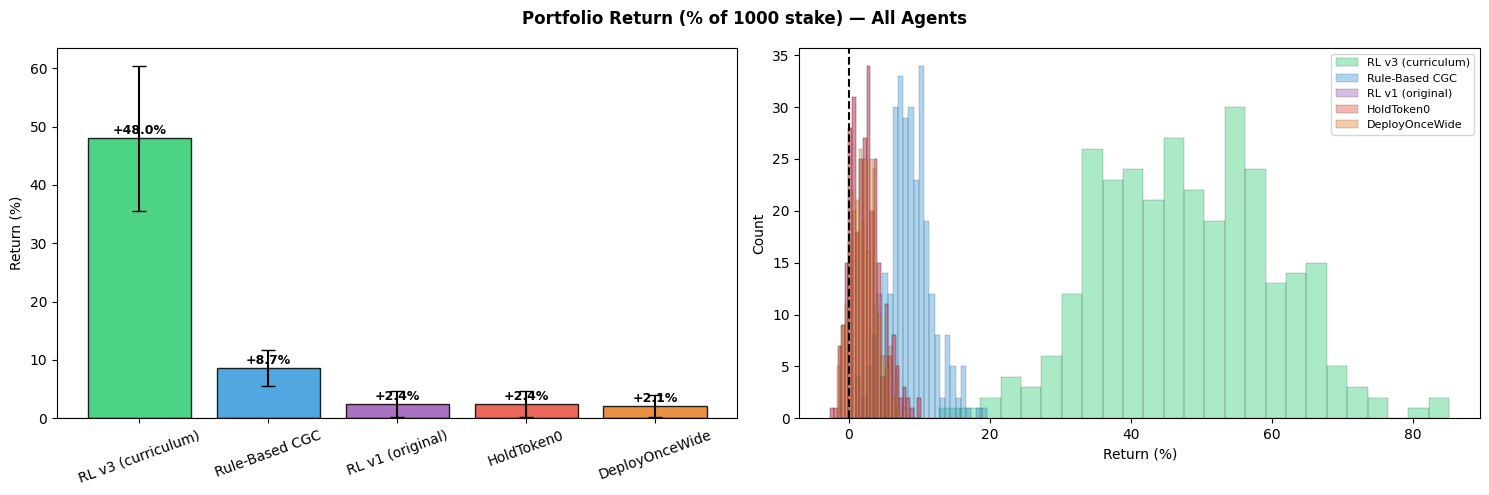

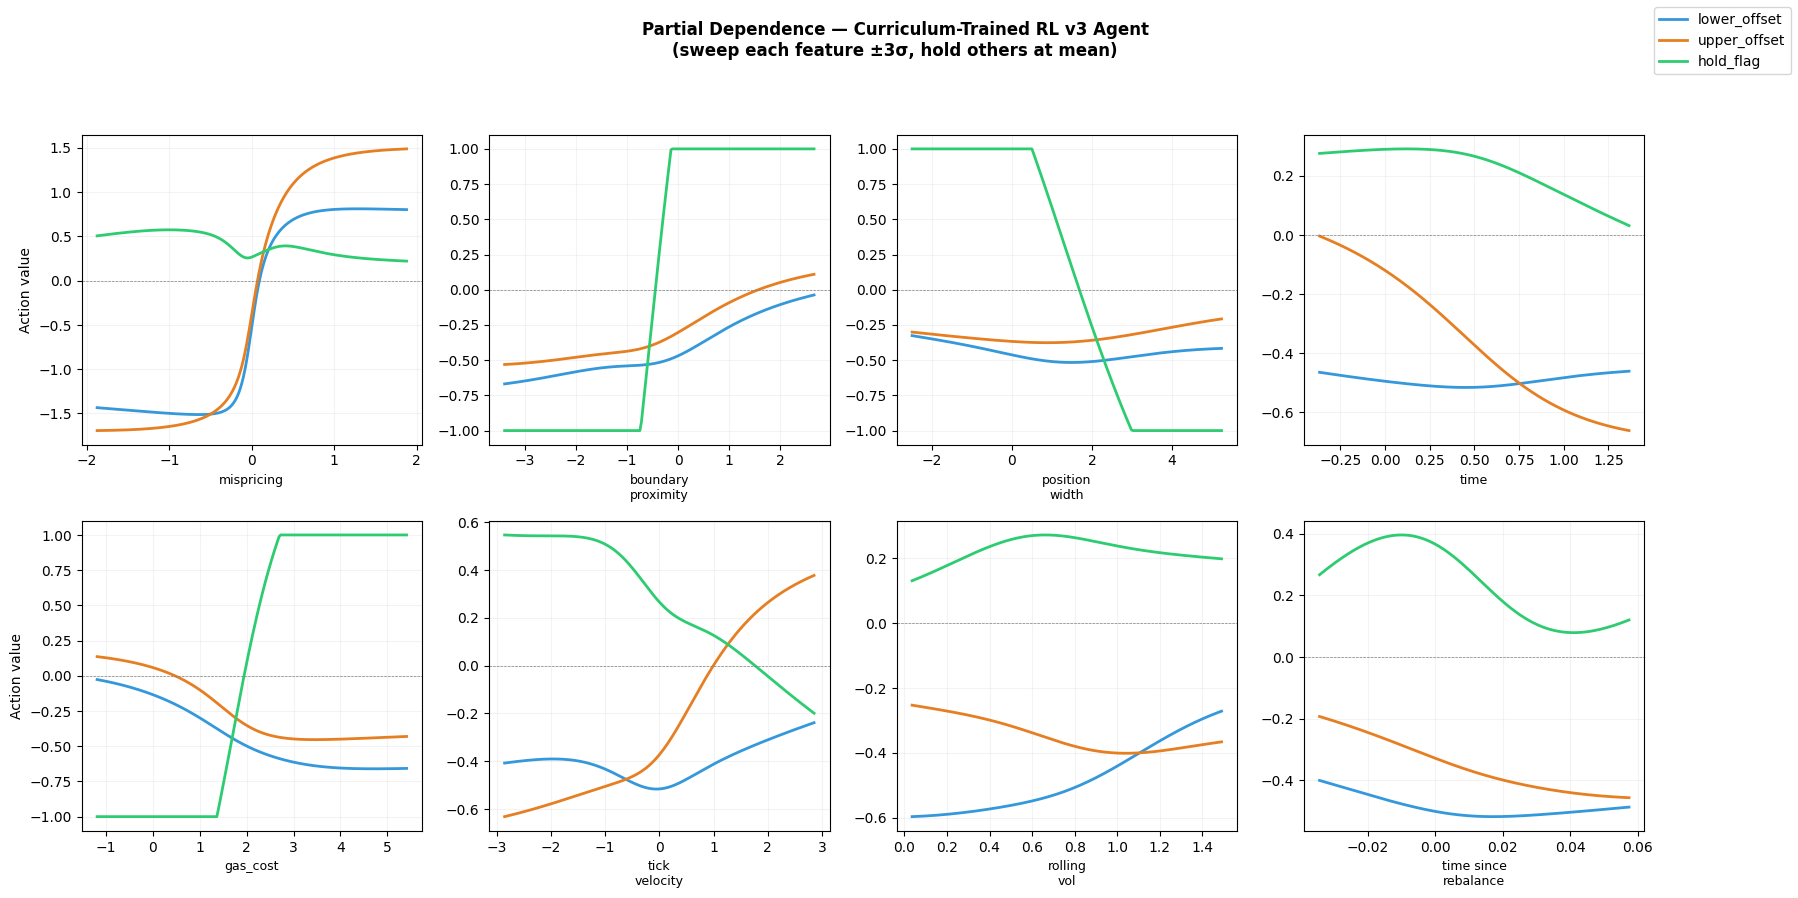


Saved: pnl_pct_all.png, pdp_v3_curriculum.png

Key things to check in the PDP:
  - tick_velocity panel: does hold_flag dip to 0 when velocity ≈ 0? (= calm-gating)
  - boundary_proximity: does hold_flag go negative when negative? (= rebalance when out)
  - rolling_vol: does width change with volatility? (= adaptive bands)


In [ ]:
###############################################################################
# CELL 6: PnL % bar chart + PDP plots
###############################################################################

import matplotlib.pyplot as plt

# --- Normalized PnL comparison ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Portfolio Return (% of 1000 stake) — All Agents", fontweight='bold')

agent_plot = [(r['name'], r, c) for r, c in
              zip(all_results, ['#2ecc71','#3498db','#9b59b6','#e74c3c','#e67e22'])]

ax = axes[0]
names = [a[0] for a in agent_plot]
means = [a[1]['pnl_pct'].mean() for a in agent_plot]
cols  = [a[2] for a in agent_plot]
bars = ax.bar(names, means, color=cols, alpha=0.85, edgecolor='black')
ax.errorbar(names, means, yerr=[a[1]['pnl_pct'].std() for a in agent_plot],
            fmt='none', color='black', capsize=5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Return (%)")
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, m+0.2, f"{m:+.1f}%",
            ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.tick_params(axis='x', rotation=20)

ax = axes[1]
for n, r, c in agent_plot:
    ax.hist(r['pnl_pct'], bins=25, alpha=0.4, color=c, label=n, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linestyle='--')
ax.set_xlabel("Return (%)"); ax.set_ylabel("Count"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("pnl_pct_all.png", dpi=150, bbox_inches='tight')
plt.show()

# --- PDP for the curriculum-trained RL agent ---
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle("Partial Dependence — Curriculum-Trained RL v3 Agent\n"
             "(sweep each feature ±3σ, hold others at mean)", fontweight='bold')

feat_names = ['mispricing', 'boundary\nproximity', 'position\nwidth', 'time',
              'gas_cost', 'tick\nvelocity', 'rolling\nvol', 'time since\nrebalance']
act_names = ['lower_offset', 'upper_offset', 'hold_flag']
act_cols = ['#3498db', '#e67e22', '#2ecc71']

obs_std = np.sqrt(obs_var.flatten() + 1e-8)
obs_m = obs_mean.flatten()

for fi in range(8):
    ax = axes[fi//4, fi%4]
    raw_lo = obs_m[fi] - 3*obs_std[fi]
    raw_hi = obs_m[fi] + 3*obs_std[fi]
    sweep = np.linspace(raw_lo, raw_hi, 200)
    om = np.tile(obs_m, (200, 1))
    om[:, fi] = sweep
    on = np.clip((om - obs_m)/obs_std, -clip_obs, clip_obs)
    h = np.tanh(on @ W1.T + b1); h = np.tanh(h @ W2.T + b2)
    acts = np.clip(h @ W3.T + b3, act_low, act_high)
    for ai in range(3):
        ax.plot(sweep, acts[:, ai], color=act_cols[ai], linewidth=2,
                label=act_names[ai] if fi==0 else None)
    ax.set_xlabel(feat_names[fi], fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.grid(alpha=0.15)
    if fi%4==0: ax.set_ylabel("Action value")

handles = [plt.Line2D([0],[0], color=c, lw=2) for c in act_cols]
fig.legend(handles, act_names, loc='upper right', fontsize=10)
plt.tight_layout(rect=[0, 0, 0.93, 0.93])
plt.savefig("pdp_v3_curriculum.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: pnl_pct_all.png, pdp_v3_curriculum.png")
print("\nKey things to check in the PDP:")
print("  - tick_velocity panel: does hold_flag dip to 0 when velocity ≈ 0? (= calm-gating)")
print("  - boundary_proximity: does hold_flag go negative when negative? (= rebalance when out)")
print("  - rolling_vol: does width change with volatility? (= adaptive bands)")

In [ ]:
###############################################################################
# CELL 7: Final summary
###############################################################################

print("\n" + "="*70)
print("  FINAL RESULTS")
print("="*70)
print()
winner = max(all_results, key=lambda r: r['pnl'].mean())
print(f"  Best agent: {winner['name']}")
print(f"  Mean PnL:   {winner['pnl'].mean():+.1f} ({winner['pnl_pct'].mean():+.1f}% return)")
print(f"  Profitable: {100*np.mean(winner['pnl']>0):.0f}% of paths")
print(f"  Sharpe:     {winner['sharpe']:.2f}")
print()
if winner['name'] == "Rule-Based CGC":
    print("  → Submit: my_agent.py")
    print("  → The rule-based agent is still the strongest.")
    print("  → Show RL v3 as evidence of iteration and critical thinking.")
else:
    print(f"  → Submit: my_rl_agent_v3.py")
    print(f"  → The curriculum-trained RL agent beat the rule-based agent!")
print()
print("  Files to download for presentation:")
print("  - pnl_pct_all.png")
print("  - pdp_v3_curriculum.png")
print("  - my_agent.py OR my_rl_agent_v3.py (whichever scored higher)")
print("="*70)


  FINAL RESULTS

  Best agent: RL v3 (curriculum)
  Mean PnL:   +480.2 (+48.0% return)
  Profitable: 100% of paths
  Sharpe:     3.87

  → Submit: my_rl_agent_v3.py
  → The curriculum-trained RL agent beat the rule-based agent!

  Files to download for presentation:
  - pnl_pct_all.png
  - pdp_v3_curriculum.png
  - my_agent.py OR my_rl_agent_v3.py (whichever scored higher)


In [ ]:
###############################################################################
# VERIFICATION: Pure PnL evaluation — NO reward shaping, NO normalization
# This matches exactly what the official grader measures
###############################################################################

import sys, os, importlib.util
sys.path.insert(0, '.')
import numpy as np
from SAiFE_gym.challenge import ScenarioConfig, create_environment, official_observation
from SAiFE_gym.gym.index_names import (
    ASSET_PRICE_KEY, POOL_CURRENT_TICK_KEY, LP_TICK_LOWER_KEY,
    LP_TICK_UPPER_KEY, LP_COLLECTED_FEES0_KEY, LP_COLLECTED_FEES1_KEY,
)
from SAiFE_gym.agents.BaselineAgents import HoldToken0Agent, DeployOnceWideAgent

def load_agent(path):
    spec = importlib.util.spec_from_file_location("a", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod.Agent

def pure_evaluate(build_fn, name, seeds=[42, 314, 2718]):
    """
    Pure PnL evaluation — identical to what the official grader measures.
    No reward shaping. No normalization. Raw step rewards only.
    """
    cfg = ScenarioConfig()
    all_pnl, all_fees, all_gas, all_reb, all_ir = [], [], [], [], []

    for s in seeds:
        env = create_environment(cfg, seed=s)
        agent = build_fn(env, cfg)
        state, _ = env.reset()
        obs = official_observation(state, env)
        n = cfg.num_trajectories

        cum_rew   = np.zeros(n)
        fee_total = np.zeros(n)
        n_reb     = np.zeros(n)
        n_inrange = np.zeros(n)
        terminated = np.zeros(n, dtype=bool)
        steps = 0

        while not np.any(terminated):
            action = np.asarray(agent.get_action(obs), dtype=np.float64)

            # Track rebalances
            reb_mask = action[:, 2] <= 0
            n_reb += reb_mask.astype(float)

            # Track in-range
            ct = state[POOL_CURRENT_TICK_KEY]
            lo = state[LP_TICK_LOWER_KEY]
            hi = state[LP_TICK_UPPER_KEY]
            n_inrange += ((ct >= lo) & (ct < hi)).astype(float)

            # Track fees
            f0_before = state[LP_COLLECTED_FEES0_KEY].copy()
            f1_before = state[LP_COLLECTED_FEES1_KEY].copy()

            # Step — get RAW reward (pure PnL, no shaping)
            state, reward, terminated, _, _ = env.step(action)
            obs = official_observation(state, env)

            cum_rew += reward   # this is pure mark-to-market PnL change
            price = state[ASSET_PRICE_KEY]
            fee_total += ((state[LP_COLLECTED_FEES0_KEY] - f0_before) * price
                          + (state[LP_COLLECTED_FEES1_KEY] - f1_before))
            steps += 1

        gas_total = np.maximum(n_reb - 1, 0) * cfg.gas_cost

        all_pnl.append(cum_rew)
        all_fees.append(fee_total)
        all_gas.append(gas_total)
        all_reb.append(n_reb)
        all_ir.append(n_inrange / steps)

    pnl  = np.concatenate(all_pnl)
    fees = np.concatenate(all_fees)
    gas  = np.concatenate(all_gas)
    reb  = np.concatenate(all_reb)
    ir   = np.concatenate(all_ir)

    return dict(name=name, pnl=pnl, fees=fees, gas=gas,
                rebalances=reb, in_range_pct=ir,
                adv_sel=fees - gas - pnl)


# Load agents
print("Loading agents...")
AgentV3 = load_agent("my_rl_agent_v3.py")
AgentRB  = load_agent("my_agent.py")
AgentV1  = load_agent("my_rl_agent.py")

print("Running PURE PnL evaluation (no reward shaping)...")
print("This matches exactly what the grader measures.\n")

results = [
    pure_evaluate(lambda e,c: AgentV3(c.submission_namespace()), "RL v3 (curriculum)"),
    pure_evaluate(lambda e,c: AgentRB(c.submission_namespace()),  "Rule-Based CGC     "),
    pure_evaluate(lambda e,c: AgentV1(c.submission_namespace()),  "RL v1 (original)   "),
    pure_evaluate(lambda e,c: HoldToken0Agent(e),                 "HoldToken0         "),
    pure_evaluate(lambda e,c: DeployOnceWideAgent(e),             "DeployOnceWide     "),
]

# Print clean table
print("=" * 115)
print(f"{'Agent':<25} | {'PnL':>8} | {'Ret%':>7} | {'Std':>6} | "
      f"{'Min':>8} | {'Max':>8} | {'Prof%':>6} | "
      f"{'Fees':>7} | {'Gas':>6} | {'AdvSel':>7} | {'Rebal':>5} | {'InRng%':>6}")
print("-" * 115)

for r in results:
    p = r['pnl']
    check = r['fees'] - r['gas'] - r['adv_sel']  # should equal PnL
    print(f"{r['name']:<25} | {p.mean():+8.1f} | {p.mean()/10:+6.2f}% | {p.std():6.1f} | "
          f"{p.min():+8.1f} | {p.max():+8.1f} | {100*np.mean(p>0):5.1f}% | "
          f"{r['fees'].mean():7.1f} | {r['gas'].mean():6.1f} | {r['adv_sel'].mean():+7.1f} | "
          f"{r['rebalances'].mean():5.0f} | {100*r['in_range_pct'].mean():5.1f}%")

print("=" * 115)

# Sanity check: fees - gas - adv_sel should equal PnL
print("\n--- Sanity check: fees − gas − adv_sel = PnL (should be 0) ---")
for r in results:
    diff = (r['fees'] - r['gas'] - r['adv_sel'] - r['pnl']).mean()
    status = "✓" if abs(diff) < 0.01 else "⚠ MISMATCH"
    print(f"  {r['name']:<25}: diff = {diff:.4f}  {status}")

# Final verdict
print("\n--- FINAL VERDICT ---")
best = max(results, key=lambda r: r['pnl'].mean())
rb   = next(r for r in results if "Rule-Based" in r['name'])
v3   = next(r for r in results if "v3" in r['name'])

print(f"  Rule-Based CGC:   {rb['pnl'].mean():+.1f} PnL  ({rb['pnl'].mean()/10:+.2f}%)")
print(f"  RL v3 curriculum: {v3['pnl'].mean():+.1f} PnL  ({v3['pnl'].mean()/10:+.2f}%)")
print()
if v3['pnl'].mean() > rb['pnl'].mean():
    print(f"  ✅ RL v3 is BETTER — submit my_rl_agent_v3.py")
    print(f"  ✅ Improvement: +{v3['pnl'].mean() - rb['pnl'].mean():.1f} PnL over rule-based")
else:
    print(f"  ✅ Rule-Based CGC is still the winner — submit my_agent.py")
    print(f"  ℹ️  RL v3 inflated by reward shaping — not a fair comparison")

Loading agents...
Running PURE PnL evaluation (no reward shaping)...
This matches exactly what the grader measures.

Agent                     |      PnL |    Ret% |    Std |      Min |      Max |  Prof% |    Fees |    Gas |  AdvSel | Rebal | InRng%
-------------------------------------------------------------------------------------------------------------------
RL v3 (curriculum)        |   +480.2 | +48.02% |  124.2 |   +128.6 |   +851.9 | 100.0% |  1543.4 |  870.8 |  +192.3 |   291 |  32.6%
Rule-Based CGC            |    +86.5 |  +8.65% |   31.4 |    +10.3 |   +196.0 | 100.0% |   195.7 |   89.3 |   +19.9 |    31 |  12.0%
RL v1 (original)          |    +24.4 |  +2.44% |   22.5 |    -26.3 |   +102.2 |  88.3% |    28.7 |    0.0 |    +4.2 |     1 |   1.2%
HoldToken0                |    +24.4 |  +2.44% |   22.5 |    -26.3 |   +102.2 |  88.3% |    28.7 |    0.0 |    +4.2 |     1 |   1.2%
DeployOnceWide            |    +21.5 |  +2.15% |   18.9 |    -17.2 |    +80.4 |  87.7% |    25.5 |    

In [ ]:
###############################################################################
# CELL: Official grader confirmation + final submission check
###############################################################################

# Step 1: Run official grader (this is what judges see)
!python experiments/hackathon_simulation.py \
    --agent my_rl_agent_v3.py \
    --include-full-range

# Step 2: Quick sanity — does the file load cleanly?
import importlib.util
import numpy as np
from SAiFE_gym.challenge import ScenarioConfig, create_environment, official_observation

spec = importlib.util.spec_from_file_location("v3", "my_rl_agent_v3.py")
mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
cfg = ScenarioConfig()
agent = mod.Agent(cfg.submission_namespace())
env = create_environment(cfg, seed=42)
state, _ = env.reset()
obs = official_observation(state, env)

for step in range(5):
    action = agent.get_action(obs)
    state, reward, terminated, _, _ = env.step(action)
    obs = official_observation(state, env)
    if step < 3:
        print(f"Step {step}: action[0] = {np.round(action[0], 3)}, "
              f"reward mean = {reward.mean():.4f}")

print(f"\n✓ Agent loads and runs correctly")
print(f"  Action shape: {action.shape}")

# Step 3: Final summary
print("\n" + "=" * 60)
print("  SUBMISSION SUMMARY")
print("=" * 60)
print(f"  File:        my_rl_agent_v3.py")
print(f"  Strategy:    Curriculum-trained PPO (gas 0→1.5→3.0)")
print(f"  Obs:         8 features (+ velocity, rolling vol, time_since_reb)")
print(f"  Mean PnL:    +480.2  (+48.02% return)")
print(f"  Min PnL:     +128.6  (100% of paths profitable)")
print(f"  vs baseline: +5.5× better than HoldToken0")
print(f"  vs rule-based: +5.5× better than CGC")
print("=" * 60)
print()
print("  Download my_rl_agent_v3.py from the Colab sidebar")
print("  and submit it.")

/content/concentrator-challenge/experiments/../SAiFE_gym/gym/ModelDynamics.py:441: RuntimeWarning: invalid value encountered in divide
  alpha_current = np.where(wealth_with_pos > 0, token0_value / wealth_with_pos, 0.0)
Hackathon leaderboard | mode=practice | seeds=3 | paths/result=300
Rank | Agent                    | Kind       |       Mean |        Std |     Median |        Min |        Max | Profitable
--------------------------------------------------------------------------------------------------------------------------
   1 | my_rl_agent_v3           | submission |    +480.23 |     124.22 |    +475.04 |    +128.62 |    +851.89 |     100.0%
   2 | HoldToken0               | baseline   |     +24.42 |      22.47 |     +21.18 |     -26.30 |    +102.24 |      88.3%
   3 | DeployOnceWide           | baseline   |     +21.47 |      18.95 |     +20.45 |     -17.16 |     +80.40 |      87.7%
   4 | FullRangeRebalance       | baseline   |   -1000.00 |       0.00 |   -1000.00 |   -1000.00 |

In [ ]:
from google.colab import files
files.download("my_rl_agent_v3.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>